# 🔧 Predictive Maintenance Workshop: Machine Learning Pipeline for Industrial Fault Detection

## 🎯 Workshop Overview

This workshop provides a comprehensive introduction to predictive maintenance (PdM) using machine learning techniques for industrial equipment monitoring. You will develop a complete pipeline for acoustic-based fault detection in rotating machinery, from raw signal processing through model deployment.

### 🏭 Theoretical Foundation: Predictive Maintenance

Predictive maintenance represents a paradigm shift from traditional maintenance strategies:

- **🔥 Reactive Maintenance**: Corrective actions post-failure, resulting in unplanned downtime and cascading system failures
- **⏰ Preventive Maintenance**: Time-based scheduled interventions, often leading to unnecessary component replacement
- **🎯 Predictive Maintenance**: Condition-based maintenance using real-time sensor data to optimize intervention timing

The economic impact is significant: predictive maintenance can reduce maintenance costs by 25-30% and decrease breakdowns by up to 75% (McKinsey, 2017).

### Acoustic Signal Analysis for Fault Detection

Acoustic emissions provide rich information about mechanical system health. The physical principles underlying acoustic fault detection include:

1. **Vibration Propagation**: Mechanical faults alter system dynamics, changing natural frequencies and introducing new spectral components
2. **Contact Mechanics**: Surface defects (e.g., gear tooth damage) create impulsive excitations at characteristic frequencies
3. **Signal Modulation**: Faults often manifest as amplitude or frequency modulation of carrier frequencies related to shaft rotation

### 📚 Workshop Structure (12 Steps)

1. **📦 Environment Setup**: Library configuration and imports
2. **📂 Data Loading**: Dataset discovery and initialization  
3. **🔍 Exploratory Data Analysis**: Signal, temporal, and spectrogram analysis
4. **🧠 Feature Engineering**: Hierarchical feature extraction architecture and demo
5. **🔧 Feature Pipeline & Preprocessing**: Scalable extraction and standardization
6. **💥 Naive Baseline**: Demonstrating why proper ML pipeline matters
7. **🎯 Proper Baseline**: Establishing performance benchmark with best practices
8. **🏆 Multi-Algorithm Comparison**: Testing multiple algorithms across features with performance analysis and feature importance
9. **🎭 Error Analysis**: Confusion matrix and business impact assessment
10. **🎯 Production Model Training**: Final model on complete dataset
11. **💾 Model Persistence**: Serialization and loading for deployment
12. **🚀 Real-Time Deployment**: Live monitoring system and production interface

### 📚 Learning Objectives

Upon completion, you will be able to:

1. **🌊 Signal Processing**: Apply time-frequency analysis techniques to extract meaningful features from acoustic data
2. **⚙️ Feature Engineering**: Design hierarchical feature representations from raw signals to advanced statistical descriptors
3. **🤖 Model Development**: Implement and compare multiple classification algorithms for fault detection
4. **📊 Performance Evaluation**: Apply appropriate metrics for imbalanced classification problems in industrial settings
5. **🚀 Deployment Strategy**: Integrate trained models into real-time monitoring systems

### Case Study: Gear Tooth Fault Detection

**Problem Statement**: Develop a multi-class classifier to categorize gear conditions using acoustic signatures, distinguishing between healthy gears and various fault types including chipped teeth.

**Performance Requirements**: 
- High recall (sensitivity) to minimize missed detections
- Controlled false positive rate to prevent maintenance disruption
- Robust performance across varying load and speed conditions

## 📦 Step 1: Library Configuration and Environment Setup

This section initializes the computational environment and imports required libraries for signal processing, machine learning, and data visualization.

In [ ]:
%%bash
conda install -y git
!git clone https://github.com/Ibrahimhk98/FrED-Predictive-Maintenance.git

In [ ]:
# Add FrED-Predictive-Maintenance to path
import sys
sys.path.append('FrED-Predictive-Maintenance/')
#install requirements
%pip install -r FrED-Predictive-Maintenance/requirements.txt

In [1]:
# Core computational libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display

# Configure visualization parameters
plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)  # Ensure reproducible results

# Configure Python path for custom modules
feature_pipeline_path = Path('./Preparation/Sample Preparation/Feature_extraction_pipeline').resolve()
sys.path.append(str(feature_pipeline_path))

# Import custom signal processing modules
from loader import load_long_audio
from splitters import segment_train_test
from orchestrator import run_pipeline_on_dataset

print('✅ Environment configured successfully.')
print('🔧 Custom feature extraction pipeline loaded.')

✅ Environment configured successfully.
🔧 Custom feature extraction pipeline loaded.


## 📂 Step 2: Dataset Discovery and Initialization

Data inventory and validation are critical first steps in any machine learning pipeline. This section performs systematic dataset discovery and creates a structured data catalog.

In [2]:
# Define data directory and supported audio formats
data_dir = Path("data/audio")
allowed_extensions = {".wav", ".flac", ".mp3", ".m4a", ".ogg"}


# Perform recursive file discovery and cataloging
audio_files = []
for file_path in sorted(data_dir.rglob("*")):
    if file_path.is_file() and file_path.suffix.lower() in allowed_extensions:
        audio_files.append({
            "file_path": file_path,
            "label": file_path.parent.name,  # Directory-based labeling
            "filename": file_path.name
        })

# Create structured dataset catalog
df = pd.DataFrame(audio_files)

if df.empty:
    raise ValueError(f"No audio files found. Supported formats: {allowed_extensions}")

# Dataset summary
print(f"📊 Found {len(df)} audio files")
print(df['label'].value_counts())
display(df.head(3))

📊 Found 4 audio files
label
Center_Offset    1
Chipped_Tooth    1
Good             1
Vertical_Wear    1
Name: count, dtype: int64


,file_path,label,filename
0,data/audio/Center_Offset/20251021_174838.wav,Center_Offset,20251021_174838.wav
1,data/audio/Chipped_Tooth/20251022_101242.wav,Chipped_Tooth,20251022_101242.wav
2,data/audio/Good/20251021_183443.wav,Good,20251021_183443.wav


## 🔍 Step 3: Exploratory Data Analysis

Understanding your data is the foundation of successful machine learning. This section explores the acoustic signatures through multiple analysis techniques to understand signal characteristics and class separability.

### 3.1 Signal Overview

In [35]:
# Select representative sample for analysis
sample_idx = 0
sample_file = df.iloc[sample_idx]['file_path']
sample_label = df.iloc[sample_idx]['label']
sample_filename = df.iloc[sample_idx]['filename']

print(f"🔍 Sample: {sample_filename} ({sample_label})")

# Load and analyze audio data
audio_data, sample_rate = load_long_audio(sample_file,lowpass_cutoff=1000)
duration = len(audio_data) / sample_rate

print(f"📊 {duration:.1f}s, {sample_rate:,} Hz, {len(audio_data):,} samples")

# Audio preview
playback_duration = min(10, duration)
playback_samples = int(playback_duration * sample_rate)
playback_audio = audio_data[:playback_samples]
display(Audio(data=playback_audio, rate=sample_rate))

🔍 Sample: 20251021_174838.wav (Center_Offset)
📊 300.0s, 40,000 Hz, 12,000,000 samples


### 3.2 Temporal Signal Analysis

Time-domain analysis reveals fundamental signal characteristics including amplitude distribution, temporal patterns, and transient events that may indicate mechanical faults.

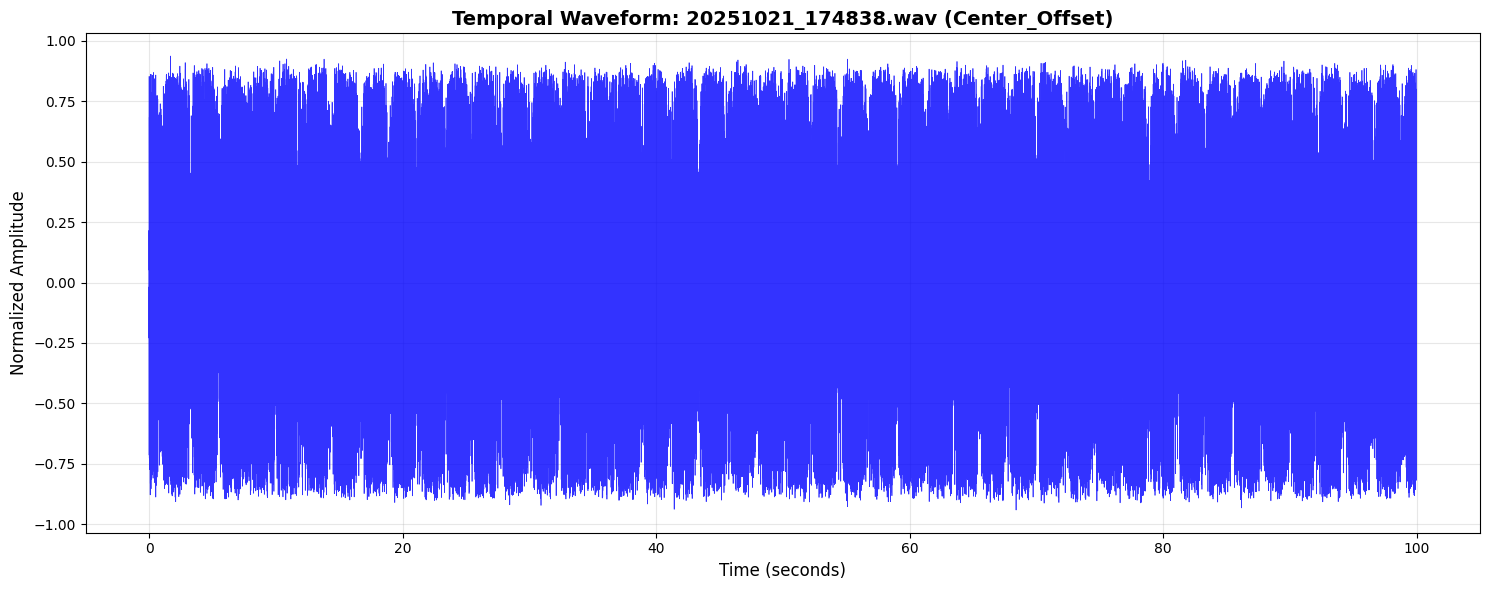

In [36]:
# Generate temporal axis
time_axis = np.linspace(0, len(audio_data[0:4000000])/sample_rate, 4000000)

# Temporal waveform visualization
plt.figure(figsize=(15, 6))
plt.plot(time_axis, audio_data[0:4000000], linewidth=0.5, alpha=0.8, color='blue')
plt.title(f'Temporal Waveform: {sample_filename} ({sample_label})', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



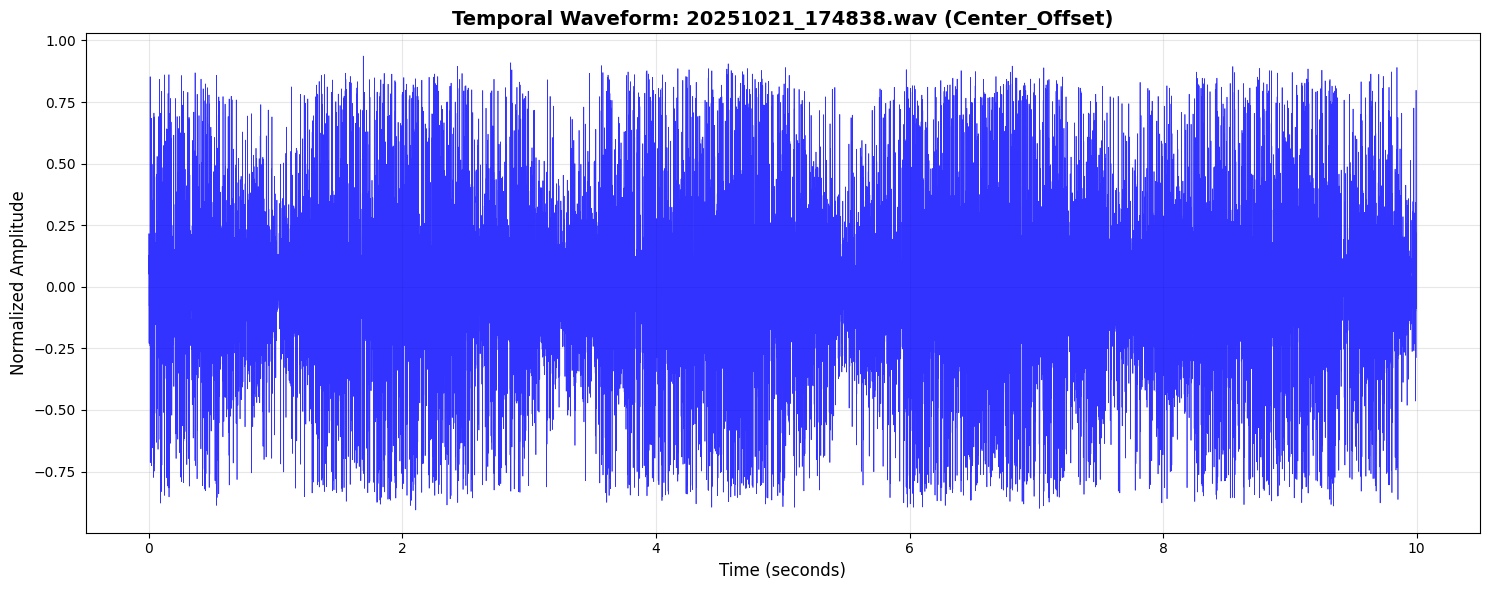

In [37]:
# Generate temporal axis
time_axis = np.linspace(0, len(audio_data[0:400000])/sample_rate, 400000)

# Temporal waveform visualization
plt.figure(figsize=(15, 6))
plt.plot(time_axis, audio_data[0:400000], linewidth=0.5, alpha=0.8, color='blue')
plt.title(f'Temporal Waveform: {sample_filename} ({sample_label})', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3 Time-Frequency Analysis via Spectrogram

Spectrograms reveal the temporal evolution of frequency content through Short-Time Fourier Transform (STFT). Mechanical faults typically manifest as characteristic frequency patterns that evolve over time, making time-frequency analysis essential for fault detection.

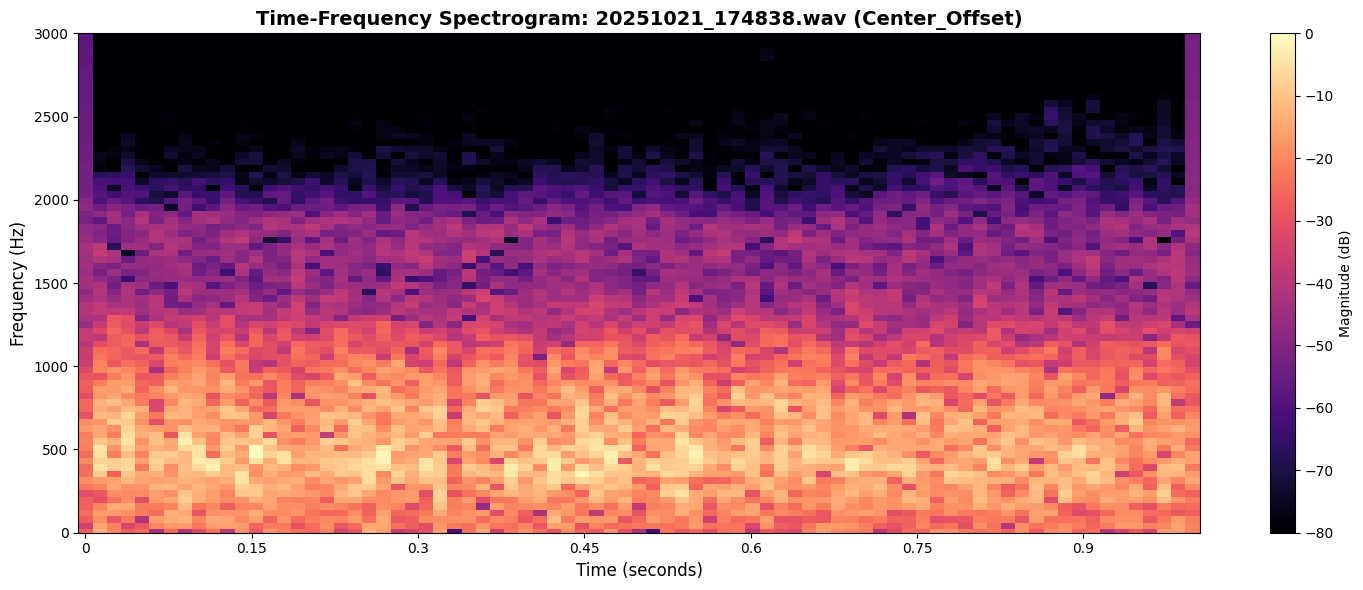

🔬 STFT: 513 freq × 79 time bins
📊 Frequency resolution: 39.1 Hz
⏱️ Time resolution: 12.8 ms


In [39]:
import librosa
import librosa.display

# STFT parameters for optimal time-frequency resolution
n_fft = 1024        # Window size: determines frequency resolution
hop_length = 512    # Frame advance: 50% overlap for smooth temporal transitions
window = 'hann'     # Hanning window for spectral leakage reduction

# Compute Short-Time Fourier Transform
stft_matrix = librosa.stft(audio_data[0:40000], n_fft=n_fft, hop_length=hop_length, window=window)
magnitude_spectrum = np.abs(stft_matrix)

# Convert to logarithmic scale for better dynamic range visualization
magnitude_db = librosa.amplitude_to_db(magnitude_spectrum, ref=np.max)

# Time-frequency visualization
plt.figure(figsize=(15, 6))
librosa.display.specshow(magnitude_db, 
                        sr=sample_rate, 
                        x_axis='time', 
                        y_axis='hz',
                        hop_length=hop_length,
                        cmap='magma')
plt.colorbar(label='Magnitude (dB)')
plt.title(f'Time-Frequency Spectrogram: {sample_filename} ({sample_label})', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Frequency (Hz)', fontsize=12)
plt.ylim(0, 3000)  # Display up to Nyquist frequency
plt.tight_layout()
plt.show()

# STFT analysis parameters
freq_resolution = sample_rate / n_fft
time_resolution = hop_length / sample_rate
num_freq_bins = magnitude_db.shape[0]
num_time_frames = magnitude_db.shape[1]

print(f"🔬 STFT: {num_freq_bins} freq × {num_time_frames} time bins")
print(f"📊 Frequency resolution: {freq_resolution:.1f} Hz")
print(f"⏱️ Time resolution: {time_resolution*1000:.1f} ms")

---
## 🧠 Step 4: Feature Engineering

Feature engineering transforms raw signals into compact, informative representations suitable for machine learning algorithms. For acoustic signals, this process is critical because:

1. **Dimensionality Reduction**: Raw audio contains 10³-10⁵ samples per second, creating computational intractability
2. **Information Extraction**: Features capture salient signal characteristics while discarding noise and irrelevant variations
3. **Domain Knowledge Integration**: Engineered features incorporate physical understanding of mechanical systems
4. **Algorithm Compatibility**: Most ML algorithms perform better on structured feature vectors than raw time series

### 4.1 Hierarchical Feature Extraction Architecture

This workshop implements a four-tier feature hierarchy with increasing computational complexity and information content:

#### 🟢 **RAW Features** (Dimensionality: ~10,000)
- **Implementation**: Temporal downsampling via uniform binning
- **Information Content**: Preserves waveform morphology with reduced resolution
- **Applications**: Deep learning architectures, convolutional neural networks
- **Advantages**: No information loss through transformation
- **Limitations**: High computational cost, requires large datasets

#### 🔵 **BASIC Features** (Dimensionality: ~15)
- **Implementation**: First and second-order temporal statistics
- **Feature Set**: Mean, variance, skewness, kurtosis, energy, zero-crossing rate
- **Applications**: Baseline models, rapid prototyping, interpretable analysis
- **Advantages**: Computational efficiency, intuitive interpretation
- **Limitations**: Limited discriminative power, no frequency domain information

#### 🟡 **STANDARD Features** (Dimensionality: ~80) 
- **Implementation**: Comprehensive time-frequency analysis
- **Feature Set**: 
  - **Temporal**: Basic statistics, energy distribution
  - **Spectral**: MFCCs, spectral centroid, bandwidth, rolloff
  - **Harmonic**: Chroma features, tonal characteristics
  - **Rhythmic**: Tempo estimation, beat tracking
- **Applications**: General-purpose fault detection, balanced performance
- **Advantages**: Robust performance across diverse fault types
- **Limitations**: Moderate computational overhead

#### 🔴 **ADVANCED Features** (Dimensionality: ~100)
- **Implementation**: Nonlinear dynamics and information theory
- **Feature Set**: 
  - **Hjorth Parameters**: Activity, mobility, complexity
  - **Entropy Measures**: Sample entropy, permutation entropy
  - **Spectral Entropy**: Frequency domain randomness quantification
- **Applications**: Complex fault patterns, subtle anomaly detection
- **Advantages**: Maximum information extraction capability
- **Limitations**: Computational intensity, potential overfitting

### Workshop Feature Selection Rationale

This workshop emphasizes **Basic** and **Standard** features for pedagogical and practical considerations:

- **Computational Efficiency**: Enables real-time workshop execution
- **Interpretability**: Facilitates understanding of feature-fault relationships  
- **Generalization**: Reduces overfitting risk with limited training data
- **Industry Relevance**: Represents practical industrial deployment constraints

### 4.2 Feature Extraction Demo

This section demonstrates feature extraction across complexity levels using a representative 5-second audio segment. The analysis reveals the information content and computational characteristics of each feature tier.

🎬 Analysis: 10.0s-11.0s (40,000 samples)


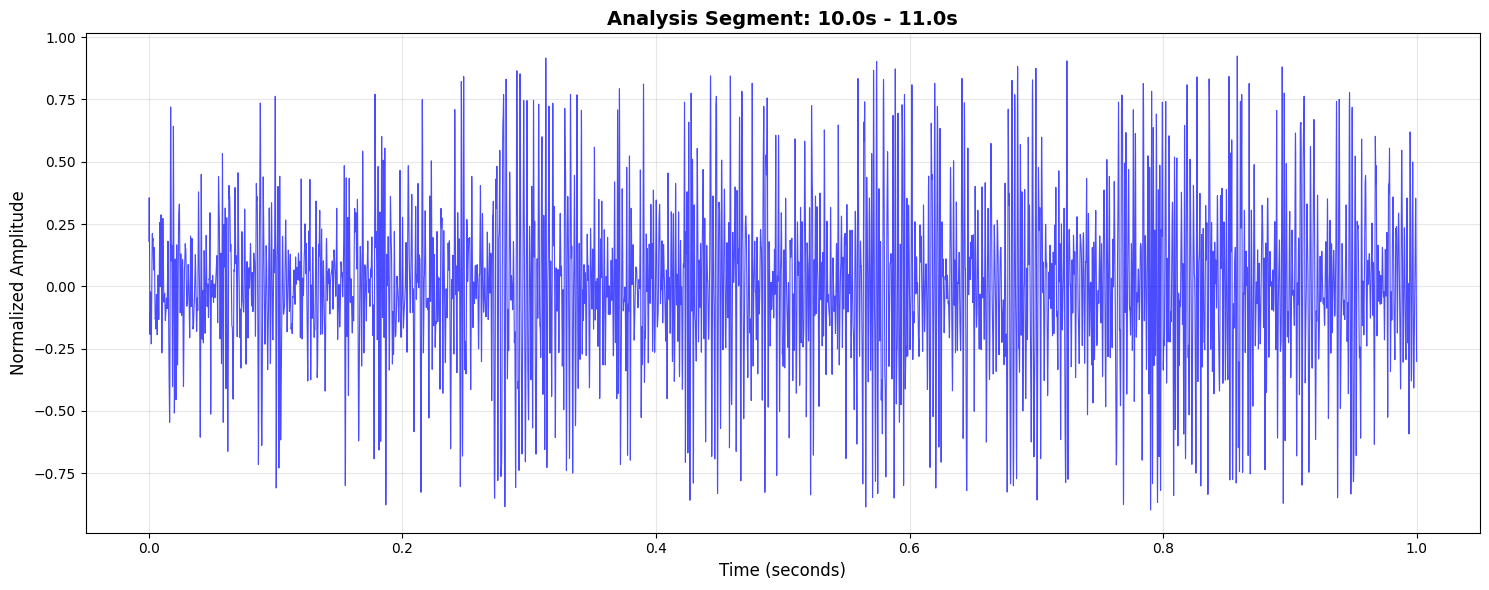

📊 Peak: 0.925, RMS: 0.309, Energy: 3829


In [7]:
# Extract representative analysis segment
segment_start = 10.0  # Analysis window start time (seconds)
segment_duration = 1.0  # Analysis window duration (seconds)

# Calculate sample boundaries
start_sample = int(segment_start * sample_rate)
end_sample = int((segment_start + segment_duration) * sample_rate)

# Extract temporal segment
demo_segment = audio_data[start_sample:end_sample]
demo_time = np.linspace(0, segment_duration, len(demo_segment))

print(f"🎬 Analysis: {segment_start}s-{segment_start + segment_duration}s ({len(demo_segment):,} samples)")
display(Audio(data=demo_segment, rate=sample_rate))

# Temporal visualization of analysis segment
plt.figure(figsize=(15, 6))
plt.plot(demo_time, demo_segment, linewidth=0.8, color='blue', alpha=0.7)
plt.title(f'Analysis Segment: {segment_start}s - {segment_start + segment_duration}s', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Segment statistical characterization
peak_amplitude = np.max(np.abs(demo_segment))
rms_value = np.sqrt(np.mean(demo_segment**2))
total_energy = np.sum(demo_segment**2)

print(f"📊 Peak: {peak_amplitude:.3f}, RMS: {rms_value:.3f}, Energy: {total_energy:.0f}")

### 🟢 RAW Features: Temporal Binning Analysis

RAW features implement temporal downsampling through uniform binning, reducing dimensionality while preserving essential waveform characteristics. This approach maintains temporal structure necessary for deep learning architectures.

🟢 RAW: 40,000 → 1,000 features (40:1 compression)


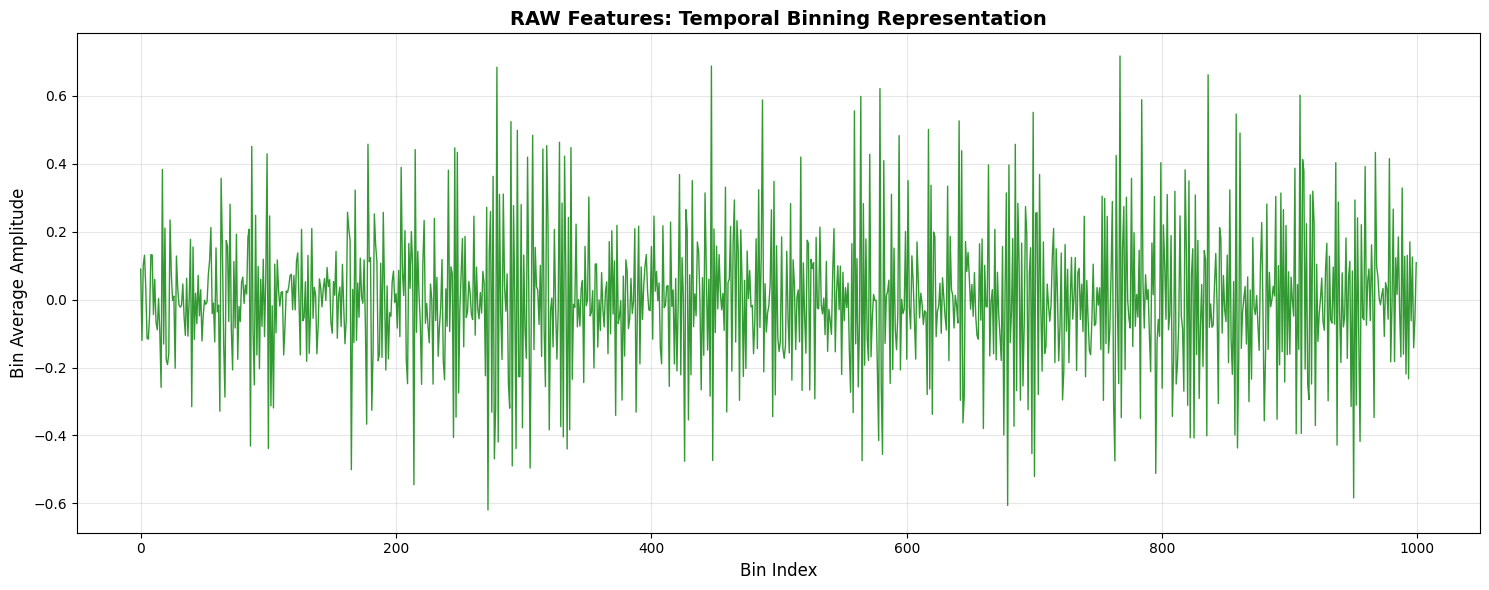

📊 Range: [-0.620, 0.717], Mean: 0.002


In [8]:
# RAW features: Temporal binning implementation
from rich_features import extract_features_for_list

# Configure binning parameters
n_raw_features = 1000  # Target feature dimensionality
samples_per_bin = len(demo_segment) // n_raw_features

# Implement uniform temporal binning
raw_features = []
for i in range(n_raw_features):
    start_idx = i * samples_per_bin
    end_idx = min((i + 1) * samples_per_bin, len(demo_segment))
    
    if start_idx < len(demo_segment):
        # Average samples within each bin
        bin_average = np.mean(demo_segment[start_idx:end_idx])
        raw_features.append(bin_average)
    else:
        raw_features.append(0.0)

raw_features = np.array(raw_features)

# Dimensionality reduction analysis
original_samples = len(demo_segment)
compressed_features = len(raw_features)
compression_ratio = original_samples / compressed_features

print(f"🟢 RAW: {original_samples:,} → {compressed_features:,} features ({compression_ratio:.0f}:1 compression)")

# Visualization of binned features
plt.figure(figsize=(15, 6))
plt.plot(raw_features, linewidth=1.0, color='green', alpha=0.8)
plt.title('RAW Features: Temporal Binning Representation', fontsize=14, fontweight='bold')
plt.xlabel('Bin Index', fontsize=12)
plt.ylabel('Bin Average Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical characterization
feature_min = np.min(raw_features)
feature_max = np.max(raw_features)
feature_mean = np.mean(raw_features)
feature_std = np.std(raw_features)

print(f"📊 Range: [{feature_min:.3f}, {feature_max:.3f}], Mean: {feature_mean:.3f}")

### 🔵 BASIC Features: Statistical Signal Characterization

BASIC features extract fundamental statistical descriptors from the temporal domain, providing computationally efficient signal characterization for rapid analysis and baseline model performance.

🔵 BASIC: 14 temporal statistical features extracted


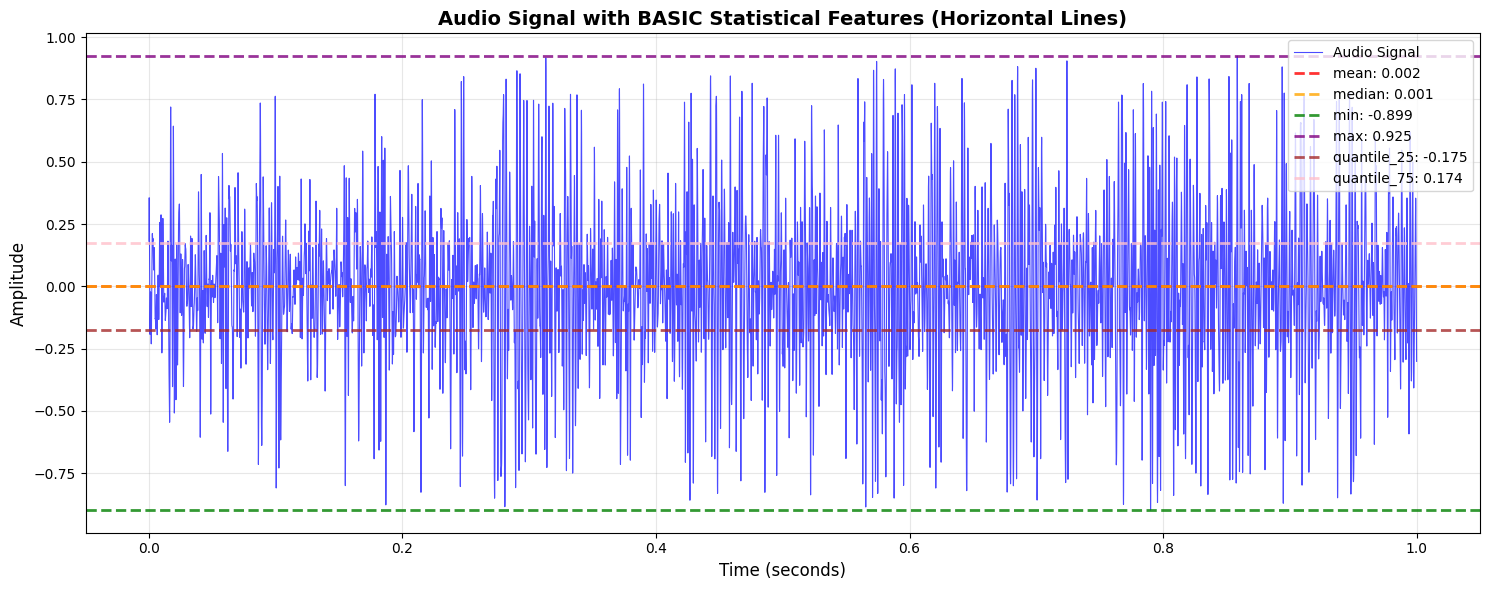

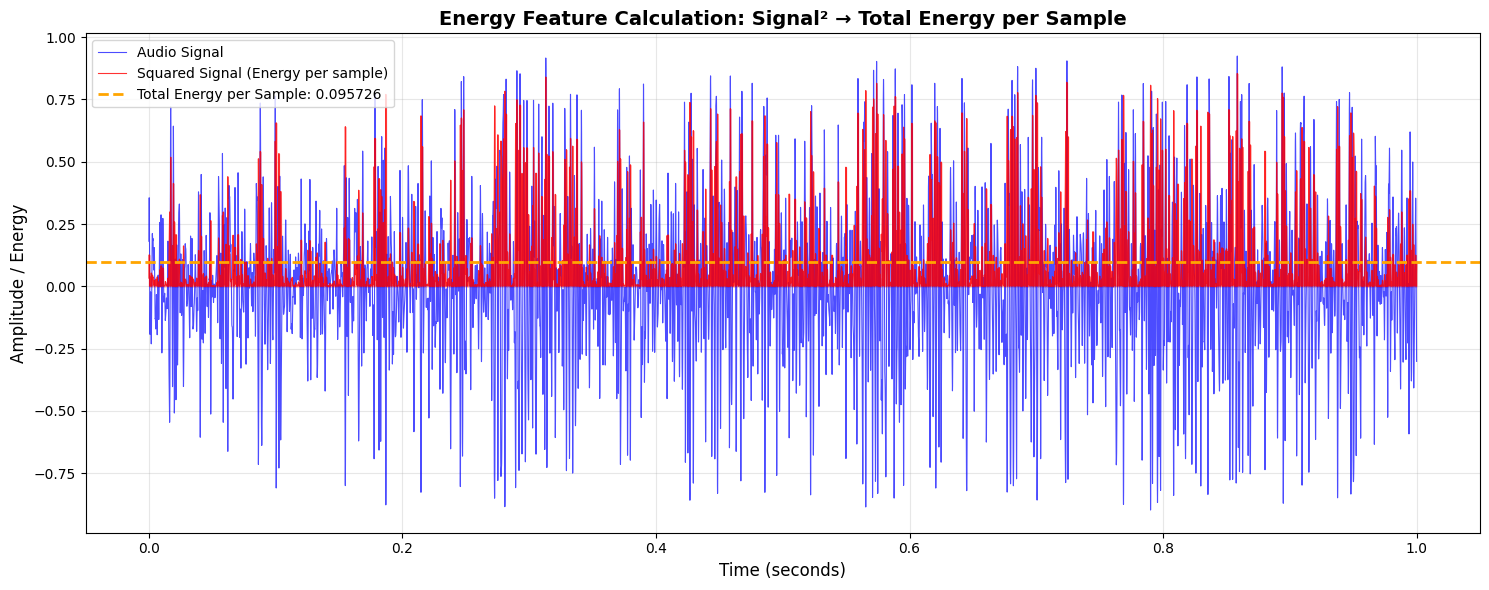

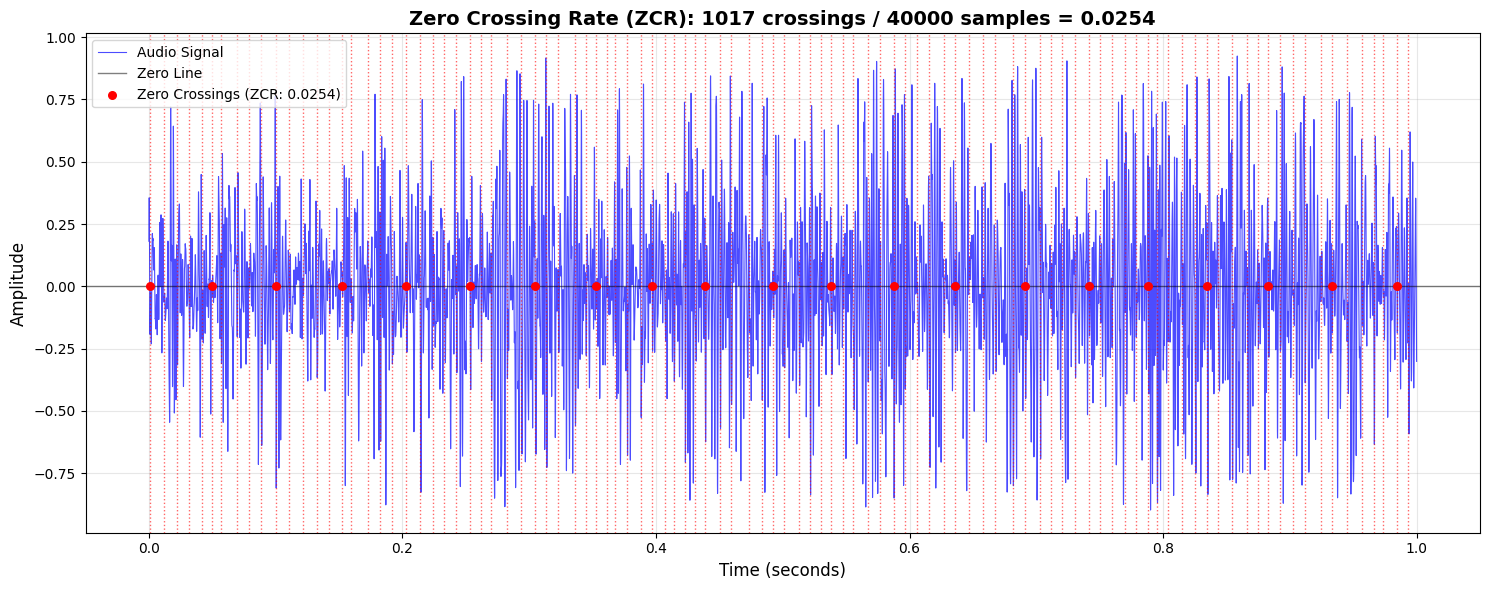

In [9]:
# 🔵 BASIC features: Temporal statistical analysis
from rich_features import extract_basic_features

# Extract temporal statistical descriptors
basic_features, basic_names = extract_basic_features(demo_segment, sample_rate)

print(f"🔵 BASIC: {len(basic_features)} temporal statistical features extracted")

# Create visualization with waveform and statistical features as horizontal lines
plt.figure(figsize=(15, 6))

# Generate time axis for the demo segment
demo_time = np.linspace(0, len(demo_segment)/sample_rate, len(demo_segment))

# Plot waveform with statistical features as horizontal lines
plt.plot(demo_time, demo_segment, linewidth=0.8, color='blue', alpha=0.7, label='Audio Signal')
plt.title('Audio Signal with BASIC Statistical Features (Horizontal Lines)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)

# Add horizontal lines for key statistical features
colors = ['red', 'orange', 'green', 'purple', 'brown', 'pink']

# Plot most interpretable features as horizontal lines
key_features = ['mean', 'median', 'min', 'max', 'quantile_25', 'quantile_75']
for i, feature_name in enumerate(key_features):
    if feature_name in basic_names:
        idx = basic_names.index(feature_name)
        feature_value = basic_features[idx]
        color = colors[i % len(colors)]
        
        plt.axhline(y=feature_value, color=color, linestyle='--', linewidth=2, 
                   alpha=0.8, label=f'{feature_name}: {feature_value:.3f}')

plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


# Plot 1: Total Energy per Sample calculation visualization
plt.figure(figsize=(15, 6))
plt.plot(demo_time, demo_segment, linewidth=0.8, color='blue', alpha=0.7, label='Audio Signal')
plt.plot(demo_time, demo_segment**2, linewidth=0.8, color='red', alpha=0.8, label='Squared Signal (Energy per sample)')
plt.axhline(y=total_energy/len(demo_segment), color='orange', linestyle='--', linewidth=2, 
           label=f'Total Energy per Sample: {total_energy/len(demo_segment):.6f}')
plt.fill_between(demo_time, demo_segment**2, alpha=0.3, color='red')
plt.title('Energy Feature Calculation: Signal² → Total Energy per Sample', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude / Energy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# Plot 2: Zero Crossing Rate calculation visualization
plt.figure(figsize=(15, 6))

# Calculate zero crossings for visualization
# Zero crossing occurs when the sign changes between adjacent samples
zero_crossings = []
for i in range(1, len(demo_segment)):
    if (demo_segment[i-1] >= 0) != (demo_segment[i] >= 0):
        zero_crossings.append(i)

zero_crossings = np.array(zero_crossings)
zcr_value = len(zero_crossings) / len(demo_segment)

plt.plot(demo_time, demo_segment, linewidth=0.8, color='blue', alpha=0.7, label='Audio Signal')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Zero Line')

# Mark zero crossings (show every 10th crossing to avoid clutter)
if len(zero_crossings) > 0:
    for crossing in zero_crossings[::10]:
        plt.axvline(x=demo_time[crossing], color='red', linestyle=':', alpha=0.6, linewidth=1)
    
    plt.scatter(demo_time[zero_crossings[::50]], np.zeros(len(zero_crossings[::50])), 
               color='red', s=30, zorder=5, label=f'Zero Crossings (ZCR: {zcr_value:.4f})')

plt.title(f'Zero Crossing Rate (ZCR): {len(zero_crossings)} crossings / {len(demo_segment)} samples = {zcr_value:.4f}', 
         fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 🟡 STANDARD Features: Multimodal Signal Analysis ⭐ **RECOMMENDED**

STANDARD features integrate temporal and spectral analysis techniques, providing comprehensive signal characterization through time-frequency decomposition, cepstral analysis, and perceptually-motivated transformations.

🟡 STANDARD Features Analysis:
   Number of features: 60
   Feature types: Time-domain + Frequency-domain + MFCCs
   Computation time: Moderate (~10-50ms)


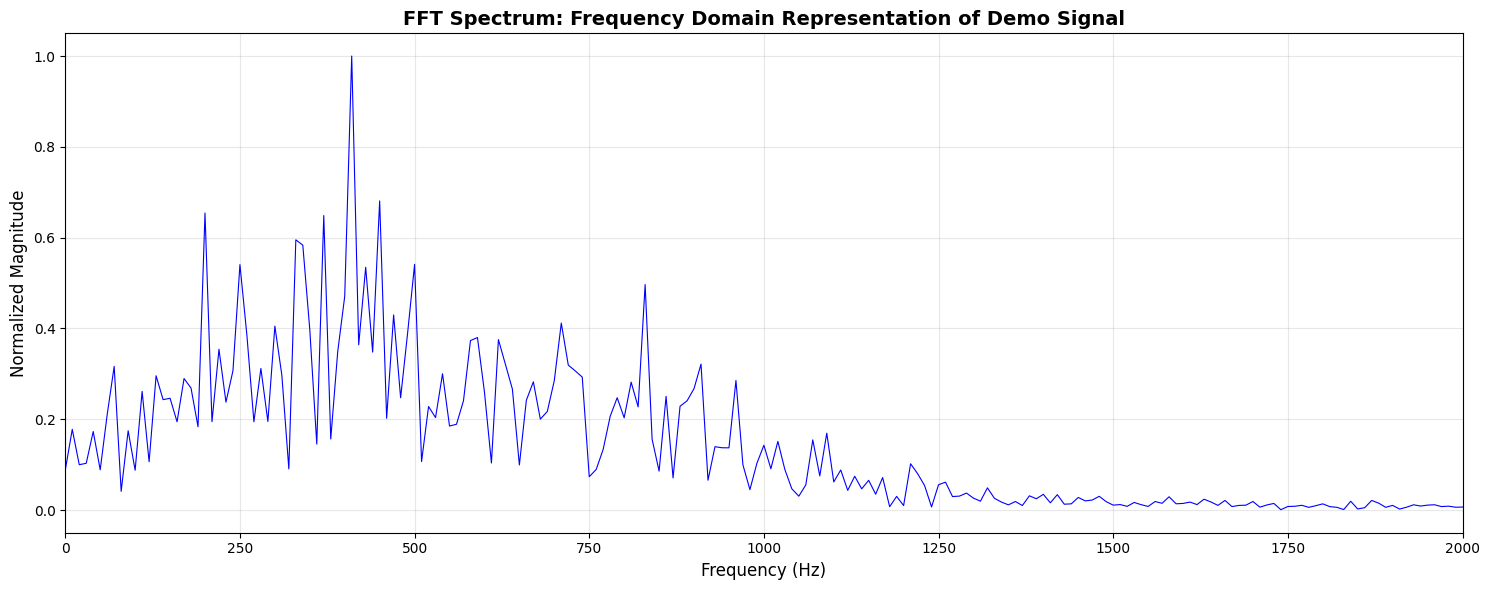

📊 FFT Analysis:
   Total frequency bins: 2000
   Frequency resolution: 10.0 Hz
   Maximum frequency: 19990 Hz


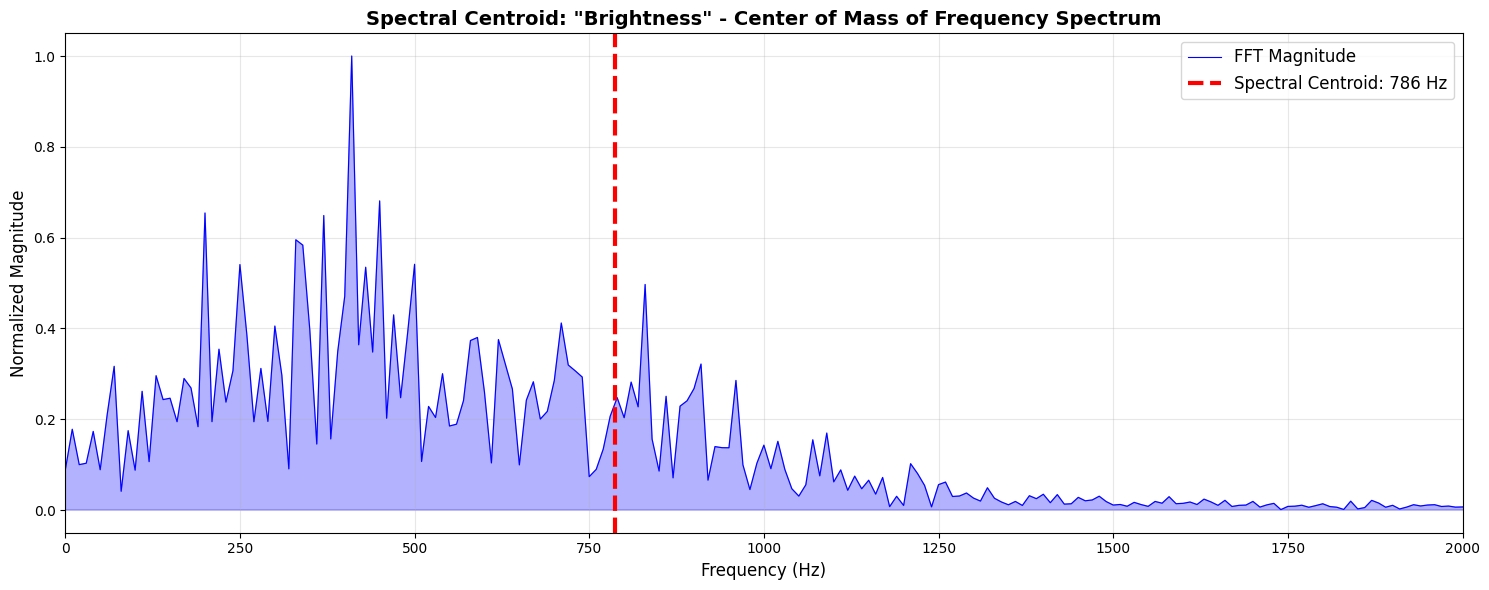

🌟 Spectral Centroid = 786 Hz
   • Higher values = 'Brighter' sound (more high-frequency content)
   • Lower values = 'Darker' sound (more low-frequency content)


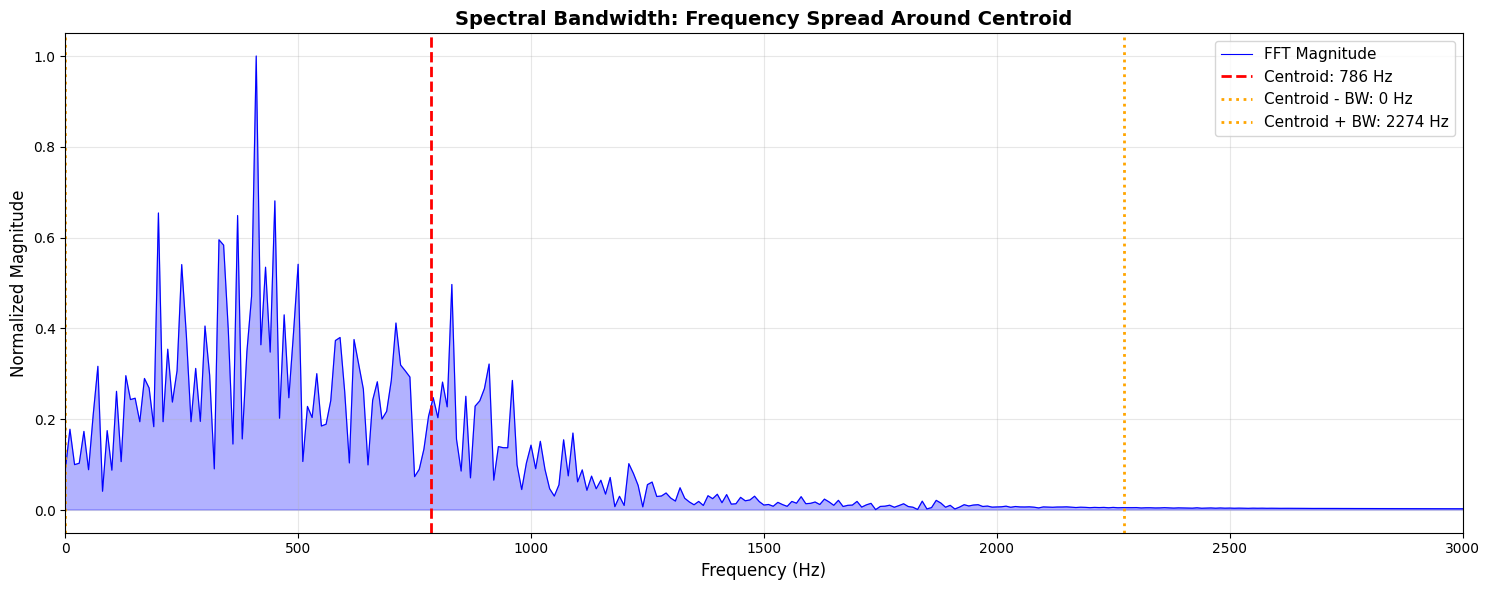

📏 Spectral Bandwidth = 1488 Hz
   • Higher values = More spread out frequencies (noisy/broadband)
   • Lower values = More concentrated frequencies (tonal/narrowband)


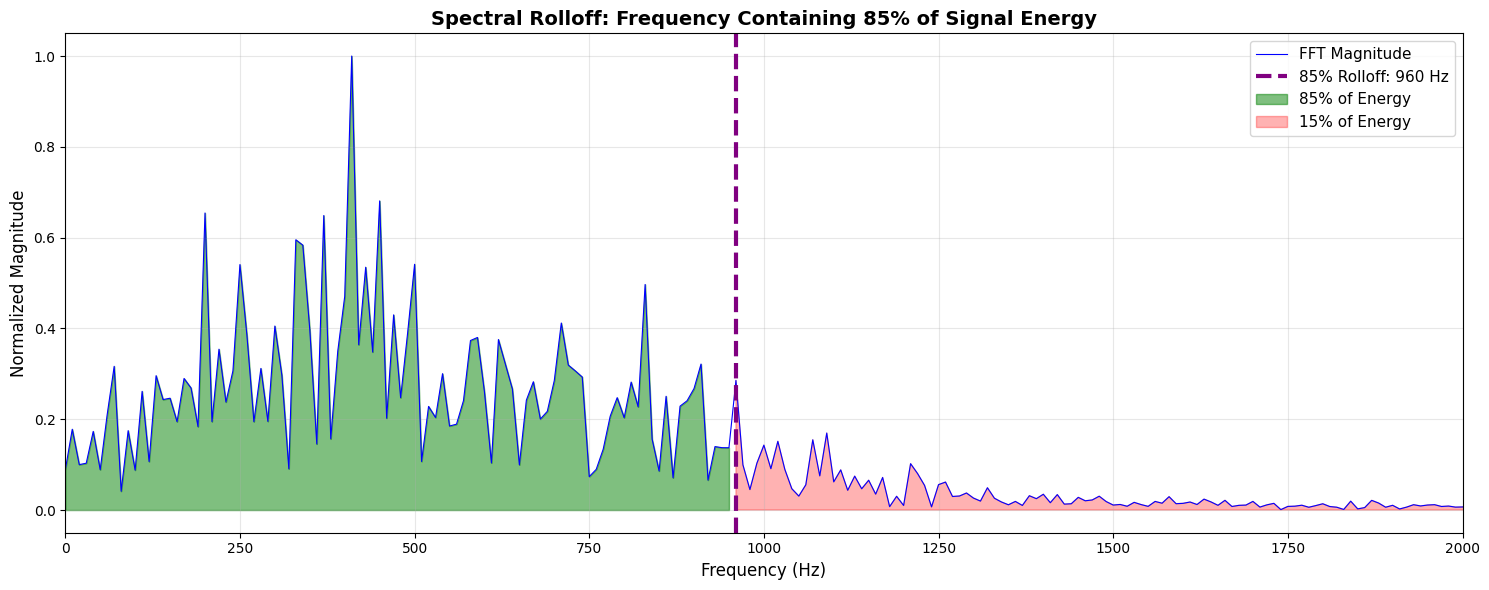

🎯 Spectral Rolloff = 960 Hz
   • Higher values = More high-frequency content
   • Lower values = Energy concentrated in low frequencies


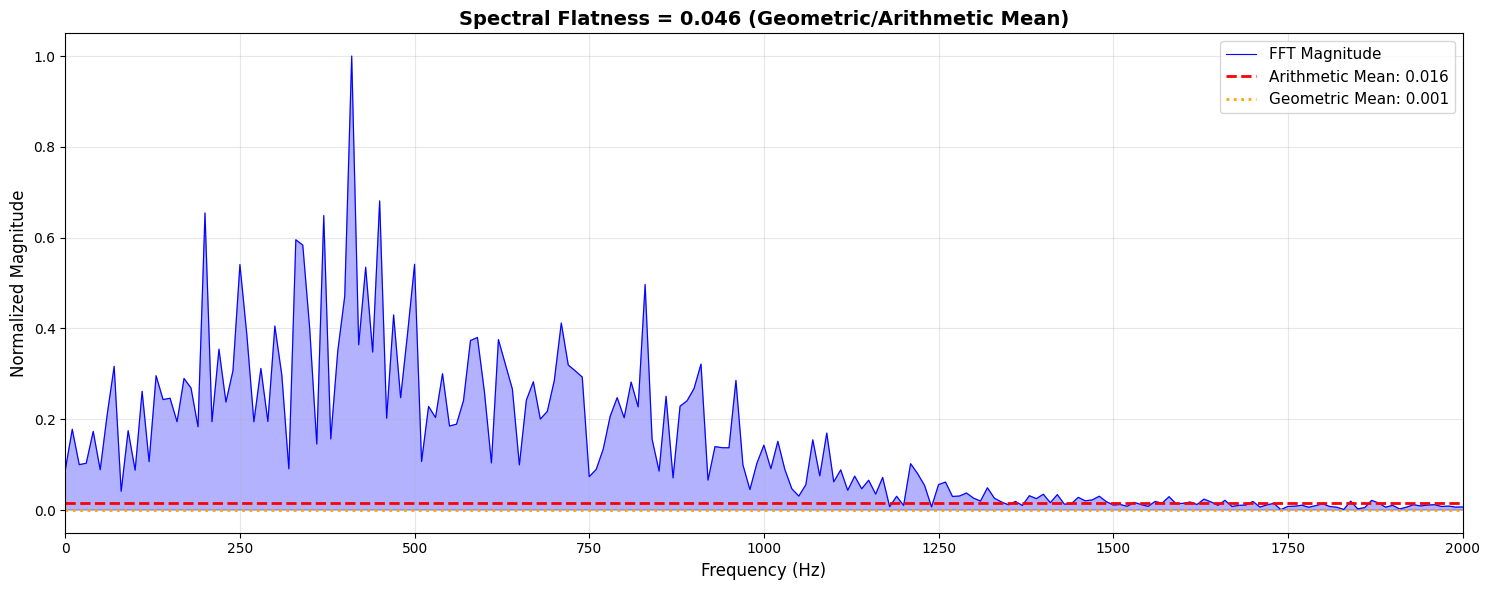

🎵 Spectral Flatness = 0.046
   • Values near 1.0 = 'Noisy' (white noise-like, flat spectrum)
   • Values near 0.0 = 'Tonal' (pitched sounds, peaky spectrum)


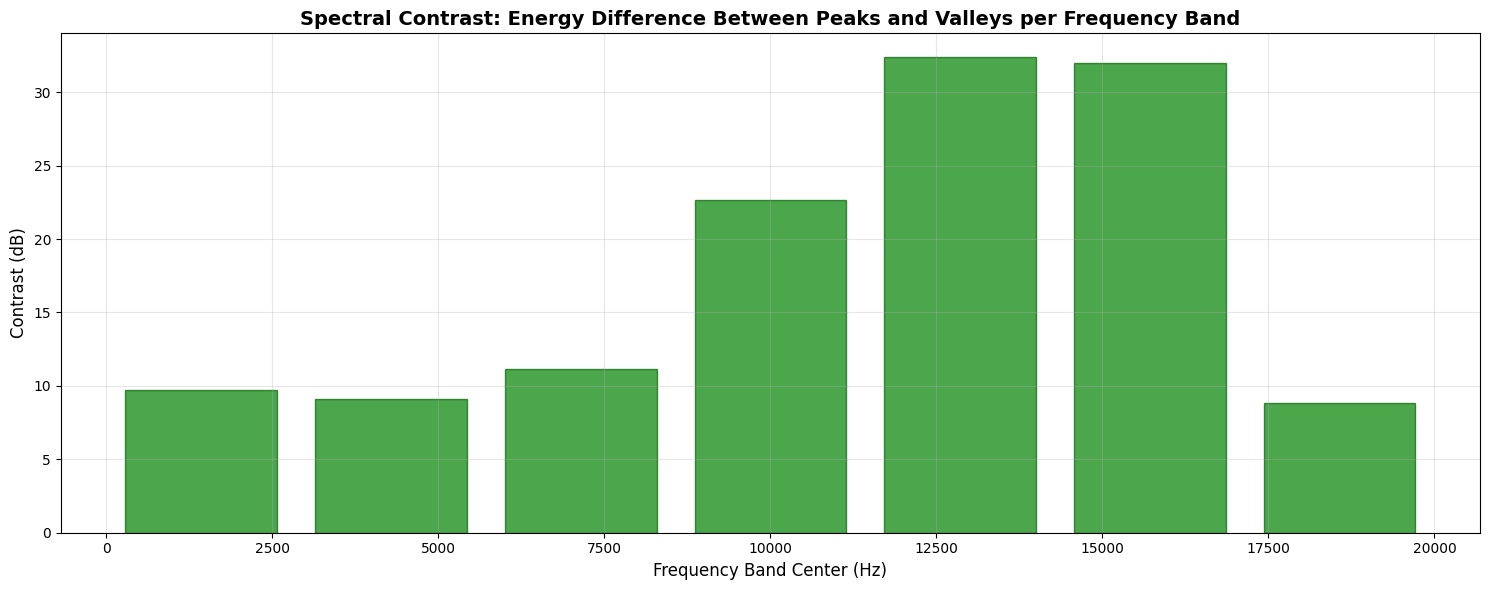

🏔️ Spectral Contrast (mean across bands): 18.0 dB
   • Higher values = Clear distinction between peaks and valleys
   • Lower values = Flatter, more uniform frequency distribution


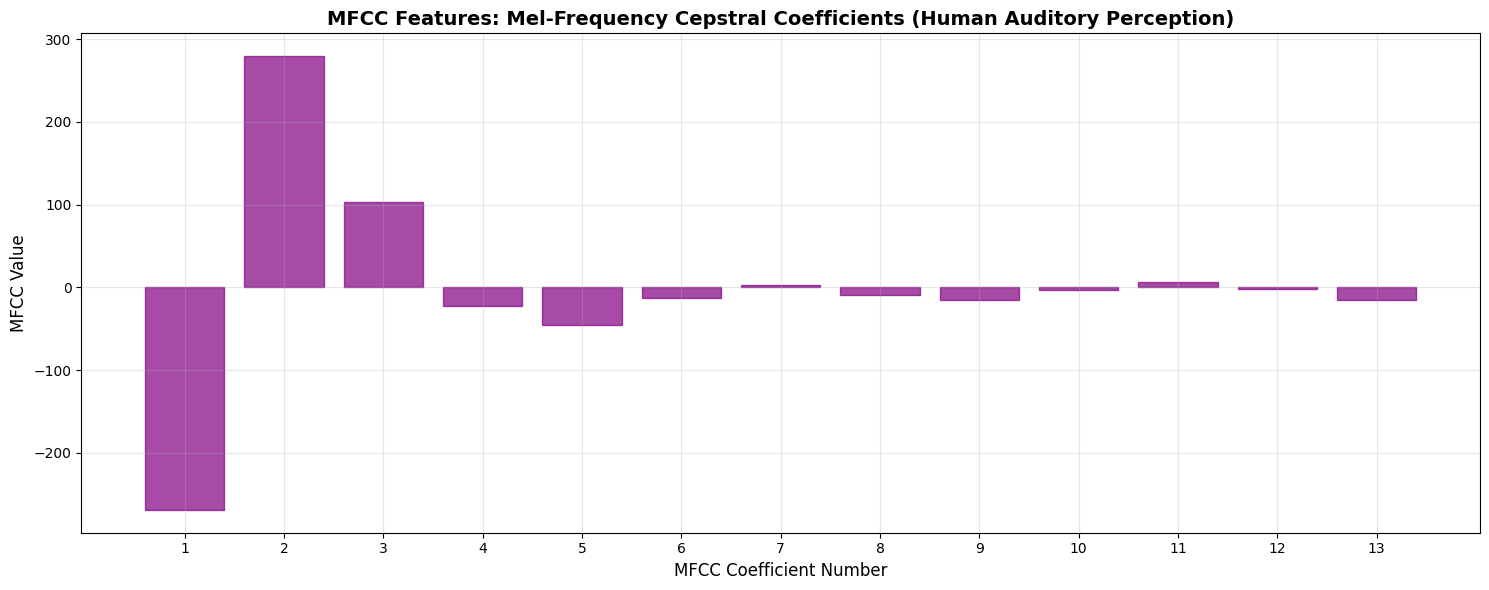

🧠 MFCC Features (13 coefficients):
   • MFCC 1-3: Overall spectral shape (most important)
   • MFCC 4-8: Mid-level spectral details
   • MFCC 9-13: Fine spectral details
   • Based on mel-scale: mimics human ear's frequency perception
   • Widely used in audio classification and speech recognition


In [41]:
# 🟡 STANDARD Features: Deep Dive into Spectral Analysis
from rich_features import extract_standard_features
import scipy.signal
import librosa

# Extract standard features from our demo segment
standard_features, standard_names = extract_standard_features(demo_segment[0:4000], sample_rate)

print(f"🟡 STANDARD Features Analysis:")
print(f"   Number of features: {len(standard_features)}")
print(f"   Feature types: Time-domain + Frequency-domain + MFCCs")
print(f"   Computation time: Moderate (~10-50ms)")

# 🔬 FUNDAMENTAL SPECTRAL ANALYSIS

# 1️⃣ Compute FFT (Frequency Domain Representation)
fft_values = np.fft.fft(demo_segment[0:4000])
fft_magnitude = np.abs(fft_values)
fft_freqs = np.fft.fftfreq(len(demo_segment[0:4000]), 1/sample_rate)

# Only keep positive frequencies (first half)
n_samples = len(demo_segment[0:4000])
positive_freqs = fft_freqs[:n_samples//2]
positive_magnitude = fft_magnitude[:n_samples//2]

# Normalize magnitude for better visualization
normalized_magnitude = positive_magnitude / np.max(positive_magnitude)

# Plot FFT Spectrum
plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8)
plt.title('FFT Spectrum: Frequency Domain Representation of Demo Signal', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)  # Focus on audible range
plt.tight_layout()
plt.show()

print(f"📊 FFT Analysis:")
print(f"   Total frequency bins: {len(positive_freqs)}")
print(f"   Frequency resolution: {positive_freqs[1] - positive_freqs[0]:.1f} Hz")
print(f"   Maximum frequency: {positive_freqs[-1]:.0f} Hz")

# 2️⃣ SPECTRAL CENTROID - "Brightness" of Sound
# Centroid = weighted average of frequencies (center of mass of spectrum)
spectral_centroid = np.sum(positive_freqs * positive_magnitude) / np.sum(positive_magnitude)

plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8, label='FFT Magnitude')
plt.axvline(x=spectral_centroid, color='red', linestyle='--', linewidth=3, 
           label=f'Spectral Centroid: {spectral_centroid:.0f} Hz')
plt.fill_between(positive_freqs, normalized_magnitude, alpha=0.3, color='blue')
plt.title('Spectral Centroid: "Brightness" - Center of Mass of Frequency Spectrum', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

print(f"🌟 Spectral Centroid = {spectral_centroid:.0f} Hz")
print(f"   • Higher values = 'Brighter' sound (more high-frequency content)")
print(f"   • Lower values = 'Darker' sound (more low-frequency content)")

# 3️⃣ SPECTRAL BANDWIDTH - Spread of frequencies around centroid
# Bandwidth = weighted standard deviation of frequencies around centroid
spectral_variance = np.sum(((positive_freqs - spectral_centroid) ** 2) * positive_magnitude) / np.sum(positive_magnitude)
spectral_bandwidth = np.sqrt(spectral_variance)

plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8, label='FFT Magnitude')
plt.axvline(x=spectral_centroid, color='red', linestyle='--', linewidth=2, 
           label=f'Centroid: {spectral_centroid:.0f} Hz')

# Only plot lower bound if it's positive
lower_bound = max(0, spectral_centroid - spectral_bandwidth)
plt.axvline(x=lower_bound, color='orange', linestyle=':', linewidth=2,
           label=f'Centroid - BW: {lower_bound:.0f} Hz')
plt.axvline(x=spectral_centroid + spectral_bandwidth, color='orange', linestyle=':', linewidth=2,
           label=f'Centroid + BW: {spectral_centroid + spectral_bandwidth:.0f} Hz')

plt.fill_between(positive_freqs, normalized_magnitude, alpha=0.3, color='blue')
plt.title('Spectral Bandwidth: Frequency Spread Around Centroid', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 3000)
plt.tight_layout()
plt.show()

print(f"📏 Spectral Bandwidth = {spectral_bandwidth:.0f} Hz")
print(f"   • Higher values = More spread out frequencies (noisy/broadband)")
print(f"   • Lower values = More concentrated frequencies (tonal/narrowband)")

# 4️⃣ SPECTRAL ROLLOFF - Frequency below which 85% of energy is contained
cumulative_energy = np.cumsum(positive_magnitude)
total_energy = cumulative_energy[-1]
rolloff_threshold = 0.85 * total_energy
rolloff_idx = np.where(cumulative_energy >= rolloff_threshold)[0][0]
spectral_rolloff = positive_freqs[rolloff_idx]

plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8, label='FFT Magnitude')
plt.axvline(x=spectral_rolloff, color='purple', linestyle='--', linewidth=3,
           label=f'85% Rolloff: {spectral_rolloff:.0f} Hz')
plt.fill_between(positive_freqs[:rolloff_idx], normalized_magnitude[:rolloff_idx], 
                alpha=0.5, color='green', label='85% of Energy')
plt.fill_between(positive_freqs[rolloff_idx:], normalized_magnitude[rolloff_idx:], 
                alpha=0.3, color='red', label='15% of Energy')
plt.title('Spectral Rolloff: Frequency Containing 85% of Signal Energy', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

print(f"🎯 Spectral Rolloff = {spectral_rolloff:.0f} Hz")
print(f"   • Higher values = More high-frequency content")
print(f"   • Lower values = Energy concentrated in low frequencies")

# 5️⃣ SPECTRAL FLATNESS - How "white noise"-like vs "tonal" the signal is
# Flatness = geometric mean / arithmetic mean of magnitude spectrum
geometric_mean = np.exp(np.mean(np.log(positive_magnitude + 1e-10)))  # Add small value to avoid log(0)
arithmetic_mean = np.mean(positive_magnitude)
spectral_flatness = geometric_mean / arithmetic_mean

plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8, label='FFT Magnitude')
plt.axhline(y=arithmetic_mean/np.max(positive_magnitude), color='red', linestyle='--', linewidth=2,
           label=f'Arithmetic Mean: {arithmetic_mean/np.max(positive_magnitude):.3f}')
plt.axhline(y=geometric_mean/np.max(positive_magnitude), color='orange', linestyle=':', linewidth=2,
           label=f'Geometric Mean: {geometric_mean/np.max(positive_magnitude):.3f}')
plt.fill_between(positive_freqs, normalized_magnitude, alpha=0.3, color='blue')
plt.title(f'Spectral Flatness = {spectral_flatness:.3f} (Geometric/Arithmetic Mean)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

print(f"🎵 Spectral Flatness = {spectral_flatness:.3f}")
print(f"   • Values near 1.0 = 'Noisy' (white noise-like, flat spectrum)")
print(f"   • Values near 0.0 = 'Tonal' (pitched sounds, peaky spectrum)")

# 6️⃣ SPECTRAL CONTRAST - Energy difference between peaks and valleys
# Using librosa for proper spectral contrast calculation
S = np.abs(librosa.stft(demo_segment.astype(float), hop_length=512))
contrast = librosa.feature.spectral_contrast(S=S, sr=sample_rate)
contrast_mean = np.mean(contrast, axis=1)

plt.figure(figsize=(15, 6))
# Create frequency bands for contrast visualization
n_bands = len(contrast_mean)
band_freqs = np.linspace(0, sample_rate/2, n_bands+1)
band_centers = (band_freqs[:-1] + band_freqs[1:]) / 2

# Calculate proper bar width to avoid overlap (use 80% of the spacing between centers)
if len(band_centers) > 1:
    bar_width = (band_centers[1] - band_centers[0]) * 0.8
else:
    bar_width = band_centers[0] * 0.1  # fallback for single band

plt.bar(band_centers, contrast_mean, width=bar_width, 
        alpha=0.7, color='green', edgecolor='darkgreen')
plt.title('Spectral Contrast: Energy Difference Between Peaks and Valleys per Frequency Band', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency Band Center (Hz)', fontsize=12)
plt.ylabel('Contrast (dB)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"🏔️ Spectral Contrast (mean across bands): {np.mean(contrast_mean):.1f} dB")
print(f"   • Higher values = Clear distinction between peaks and valleys")
print(f"   • Lower values = Flatter, more uniform frequency distribution")

# 7️⃣ MFCC FEATURES - Mel-Frequency Cepstral Coefficients
# MFCCs mimic human auditory perception using mel-scale
mfccs = librosa.feature.mfcc(y=demo_segment.astype(float), sr=sample_rate, n_mfcc=13)
mfcc_mean = np.mean(mfccs, axis=1)

plt.figure(figsize=(15, 6))
plt.bar(range(1, len(mfcc_mean)+1), mfcc_mean, alpha=0.7, color='purple', edgecolor='purple')
plt.title('MFCC Features: Mel-Frequency Cepstral Coefficients (Human Auditory Perception)', 
          fontsize=14, fontweight='bold')
plt.xlabel('MFCC Coefficient Number', fontsize=12)
plt.ylabel('MFCC Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(mfcc_mean)+1))
plt.tight_layout()
plt.show()

print(f"🧠 MFCC Features ({len(mfcc_mean)} coefficients):")
print(f"   • MFCC 1-3: Overall spectral shape (most important)")
print(f"   • MFCC 4-8: Mid-level spectral details")
print(f"   • MFCC 9-13: Fine spectral details")
print(f"   • Based on mel-scale: mimics human ear's frequency perception")
print(f"   • Widely used in audio classification and speech recognition")





## 🔧 Step 5: Feature Pipeline & Data Preprocessing

Now that we understand feature engineering theory, we'll build a scalable pipeline to extract features from all audio files and prepare the data for machine learning.

### 5.1 Scalable Feature Extraction Pipeline

This section implements a production-ready feature extraction pipeline capable of processing large audio datasets with configurable segmentation, overlap strategies, and train-test partitioning for robust model development.

In [11]:
# Configure pipeline hyperparameters
segment_duration = 5.0    # Temporal window length (seconds)
overlap_ratio = 0.5       # Inter-segment overlap coefficient  
train_ratio = 0.8         # Training partition fraction
edge_buffer = 1.0         # Boundary artifact exclusion (seconds)
lowpass_cutoff = 1000.0  # Low-pass filter cutoff frequency (Hz)

print(f"🔧 Pipeline: {segment_duration}s segments, {overlap_ratio*100:.0f}% overlap, {train_ratio:.0%} train split")

🔧 Pipeline: 5.0s segments, 50% overlap, 80% train split


### Automated Dataset Processing Architecture

Implementation of a scalable processing function that applies feature extraction across multiple complexity levels, enabling systematic performance comparison of different representation strategies.

In [12]:
def process_dataset(feature_level, data_dir=data_dir):
    """
    Process the entire audio dataset with specified feature level.
    
    Args:
        feature_level: 'raw', 'basic', or 'standard'
        data_dir: Path to audio data directory
    
    Returns:
        Dictionary with train/test data and metadata
    """
    print(f"🔄 Processing dataset with {feature_level.upper()} features...")
    
    # Use our orchestrator to process all files
    result = run_pipeline_on_dataset(
        data_dir, 
        segment_seconds=segment_duration,
        overlap=overlap_ratio,
        train_fraction=train_ratio,
        buffer_seconds=edge_buffer,
        feature_level=feature_level,
        lowpass_cutoff=lowpass_cutoff,
    )
    
    # Extract data
    X_train = result['train']['X']
    y_train = np.array(result['train']['y'])
    X_test = result['test']['X']
    y_test = np.array(result['test']['y'])
    # FIX: feature_names is inside 'train' dict, not at top level
    feature_names = result['train'].get('feature_names', [])
    
    print(f"   ✅ Train samples: {X_train.shape[0]:,} segments")
    print(f"   ✅ Test samples: {X_test.shape[0]:,} segments") 
    print(f"   ✅ Features per segment: {X_train.shape[1]:,}")
    print(f"   ✅ Classes: {np.unique(y_train)}")
    
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'feature_names': feature_names,
        'feature_level': feature_level
    }

# 🎯 Let's start with BASIC features (fast processing)
print("🚀 Starting with BASIC features for quick analysis...")
basic_data = process_dataset('basic')

# 📊 Show class distribution
print(f"\n📊 Class Distribution:")
train_counts = pd.Series(basic_data['y_train']).value_counts()
test_counts = pd.Series(basic_data['y_test']).value_counts()
print(f"   Training set: {dict(train_counts)}")
print(f"   Test set: {dict(test_counts)}")


🚀 Starting with BASIC features for quick analysis...
🔄 Processing dataset with BASIC features...
   ✅ Train samples: 376 segments
   ✅ Test samples: 44 segments
   ✅ Features per segment: 14
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']

📊 Class Distribution:
   Training set: {'Center_Offset': np.int64(94), 'Chipped_Tooth': np.int64(94), 'Good': np.int64(94), 'Vertical_Wear': np.int64(94)}
   Test set: {'Center_Offset': np.int64(11), 'Chipped_Tooth': np.int64(11), 'Good': np.int64(11), 'Vertical_Wear': np.int64(11)}


### 5.2 Feature Standardization and Train/Test Split

Feature normalization is essential for distance-based algorithms and gradient descent optimization. This section implements standardization protocols that ensure algorithmic convergence and prevent feature magnitude bias.

### 🔬 Why Feature Scaling Matters

**Scale-Sensitive Algorithms**: Neural networks, logistic regression, and KNN require uniform feature scales for optimal performance

**Mathematical Foundation**: StandardScaler applies Z-score normalization (z = (x - μ) / σ) to achieve mean ≈ 0, std ≈ 1

**Data Leakage Prevention**: Scaler must be fitted on training data only, then applied to test data using same parameters

**Label Encoding**: Converts categorical target labels to numerical format required by ML algorithms

**Performance Impact**: Proper scaling prevents feature magnitude bias and ensures faster algorithm convergence


In [13]:
# 🔧 Import ML libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def prepare_data(data_dict):
    """
    Scale features and encode labels for ML training.
    
    Args:
        data_dict: Dictionary from process_dataset()
    
    Returns:
        Dictionary with scaled features and encoded labels
    """
    # Extract data
    X_train, y_train = data_dict['X_train'], data_dict['y_train']
    X_test, y_test = data_dict['X_test'], data_dict['y_test']
    
    # 🎯 Scale features to have mean=0, std=1
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"🔄 Features scaled: {X_train.shape[1]} features, mean≈0, std≈1")
    
    # 🏷️ Encode string labels to numbers (if needed)
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)
    
    print(f"🏷️ Labels encoded: {len(label_encoder.classes_)} classes")
    
    return {
        'X_train': X_train_scaled,
        'y_train': y_train_encoded,
        'X_test': X_test_scaled, 
        'y_test': y_test_encoded,
        'scaler': scaler,
        'label_encoder': label_encoder,
        'feature_names': data_dict['feature_names'],
        'feature_level': data_dict['feature_level']
    }

# 🎯 Prepare BASIC features data
basic_prepared = prepare_data(basic_data)

print(f"\\n✅ Data preparation complete!")
print(f"   Training samples: {basic_prepared['X_train'].shape[0]:,}")
print(f"   Features: {basic_prepared['X_train'].shape[1]:,}")
print(f"   Classes: {len(np.unique(basic_prepared['y_train']))}")

🔄 Features scaled: 14 features, mean≈0, std≈1
🏷️ Labels encoded: 4 classes
\n✅ Data preparation complete!
   Training samples: 376
   Features: 14
   Classes: 4


## 💥 Step 6: Naive Baseline - A Cautionary Tale

Before we build proper baselines, let's see what happens when we take the **worst possible approach**: using raw audio data directly with a simple model and no preprocessing. This demonstrates why proper feature engineering and data preparation are crucial!

### 🚨 Why This Will Fail Spectacularly:

- **🔥 Massive Dimensionality**: Raw audio has ~200,000+ samples per segment
- **⚠️ No Feature Engineering**: No meaningful signal processing 
- **🤖 Simple Algorithm**: Basic model can't handle complex raw data
- **❌ No Preprocessing**: No scaling or normalization
- **📊 Poor Generalization**: Overfitting to noise rather than patterns

### 🎯 Learning Goal: 
Understand why **"just throw raw data at ML"** doesn't work and appreciate the value of proper signal processing!

💥 NAIVE APPROACH: Raw Features + Simple Model
⚠️  WARNING: This is intentionally BAD - for educational purposes!
🔍 Extracting raw features using process_dataset...
🔄 Processing dataset with RAW features...
   ✅ Train samples: 376 segments
   ✅ Test samples: 44 segments
   ✅ Features per segment: 1,000
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']

📊 NAIVE APPROACH RESULTS:
   🎯 Accuracy: 0.8182 (81.8%)
   🚨 Naive accuracy: 81.8% - ACCEPTABLE

📋 Classification Report:


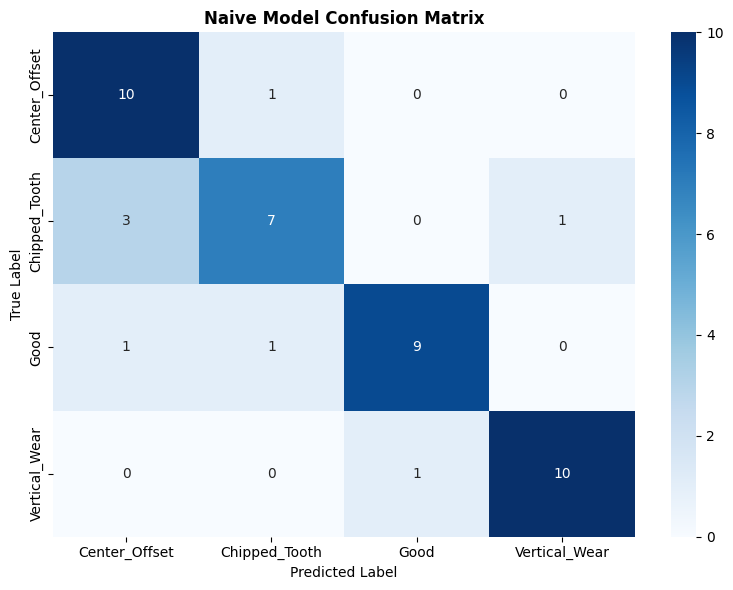

In [14]:
# 💥 Demonstrate the wrong way: Raw features + Simple model
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import time
import warnings
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("💥 NAIVE APPROACH: Raw Features + Simple Model")
print("=" * 50)
print("⚠️  WARNING: This is intentionally BAD - for educational purposes!")

# 🔥 Use process_dataset with raw feature level (minimal preprocessing)
print("🔍 Extracting raw features using process_dataset...")
raw_data = process_dataset("raw")

# Extract components from the returned dictionary
X_raw_train = raw_data['X_train']
y_raw_train = raw_data['y_train']
X_raw_test = raw_data['X_test']
y_raw_test = raw_data['y_test']
feature_names = raw_data['feature_names']
    
        
# Use default parameters (likely suboptimal)
naive_model = LogisticRegression(
    max_iter=100,     # Minimal iterations
    C=1.0,           # Default regularization
    random_state=42,
    solver='lbfgs'
)

naive_model.fit(X_raw_train, y_raw_train)

        
# Make predictions
y_pred = naive_model.predict(X_raw_test)
naive_accuracy = accuracy_score(y_raw_test, y_pred)

print(f"\n📊 NAIVE APPROACH RESULTS:")
print(f"   🎯 Accuracy: {naive_accuracy:.4f} ({naive_accuracy*100:.1f}%)")
        

# Determine performance level
if naive_accuracy < 0.6:
    performance = "POOR"
else:
    performance = "ACCEPTABLE"
    
print(f"   🚨 Naive accuracy: {naive_accuracy:.1%} - {performance}")
print(f"\n📋 Classification Report:")
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_raw_test, y_pred)
class_labels = np.unique(y_raw_test)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Naive Model Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


# Store result for comparison
naive_result = {
    'accuracy': naive_accuracy,
    'approach': 'Naive Raw Features'
}


## 🎯 Step 7: Proper Baseline Model

After seeing the naive approach fail, let's build a **proper baseline** using engineered features and systematic methodology. This demonstrates the value of good practices in machine learning pipeline development.

### 📚 Why This Baseline Will Work Better:
- ✅ **Engineered Features**: Using BASIC statistical features instead of raw data
- ✅ **Proper Preprocessing**: Standardized features and encoded labels
- ✅ **Reasonable Dimensionality**: ~15 features instead of 2000+ raw samples
- ✅ **Systematic Approach**: Following ML best practices

### 🎯 Comparison Goal:
Show dramatic improvement from naive → baseline → advanced approaches!

In [15]:
# Baseline implementation: Untuned logistic regression
from sklearn.linear_model import LogisticRegression

# Configure minimal baseline model
baseline_model = LogisticRegression(
    max_iter=100,          # Convergence limit (may terminate early)
    C=1.0,                 # L2 regularization parameter (unoptimized)
    solver='lbfgs',        # Limited-memory BFGS optimization
    random_state=42
)

print("🤖 Baseline model configuration:")
print("  Algorithm: Logistic regression with L2 regularization")
print("  Hyperparameters: Default values (untuned)")
print("  Feature set: Basic statistical descriptors")
print("  Optimization: Limited iterations")

# Model training on standardized features
baseline_model.fit(basic_prepared['X_train'], basic_prepared['y_train'])

# Generate predictions and evaluate performance
y_pred_baseline = baseline_model.predict(basic_prepared['X_test'])
baseline_accuracy = accuracy_score(basic_prepared['y_test'], y_pred_baseline)

print(f"\n📊 Baseline performance metrics:")
print(f"  🎯 Classification accuracy: {baseline_accuracy:.4f}")
print(f"  ❌ Error rate: {1-baseline_accuracy:.4f}")

# Performance limitation analysis
print(f"\n🔍 Baseline limitations (improvement opportunities):")
print(f"  ⚠️ Feature representation: Limited to temporal statistics")
print(f"  ⚠️ Model complexity: Linear decision boundary constraint")
print(f"  ⚠️ Hyperparameter optimization: No systematic tuning")
print(f"  ⚠️ Validation strategy: Single holdout evaluation")
print(f"\n📈 IMPROVEMENT FROM NAIVE APPROACH:")
if 'naive_result' in globals():
    improvement = baseline_accuracy - naive_result['accuracy']
    print(f"   💥 Naive accuracy: {naive_result['accuracy']:.4f}")
    print(f"   ✅ Baseline accuracy: {baseline_accuracy:.4f}")
    print(f"   📊 Improvement: +{improvement:.4f} ({improvement*100:.1f} percentage points)")
    if improvement > 0:
        print(f"   🎉 That's a {((baseline_accuracy/max(naive_result['accuracy'], 0.001))-1)*100:.0f}% relative improvement!")
else:
    print(f"   🎯 Goal: Beat this {baseline_accuracy:.4f} accuracy with advanced techniques!")

print(f"\n🔥 Next Goal: Exceed baseline accuracy of {baseline_accuracy:.4f} through advanced algorithms!")

🤖 Baseline model configuration:
  Algorithm: Logistic regression with L2 regularization
  Hyperparameters: Default values (untuned)
  Feature set: Basic statistical descriptors
  Optimization: Limited iterations

📊 Baseline performance metrics:
  🎯 Classification accuracy: 0.9773
  ❌ Error rate: 0.0227

🔍 Baseline limitations (improvement opportunities):
  ⚠️ Feature representation: Limited to temporal statistics
  ⚠️ Model complexity: Linear decision boundary constraint
  ⚠️ Hyperparameter optimization: No systematic tuning
  ⚠️ Validation strategy: Single holdout evaluation

📈 IMPROVEMENT FROM NAIVE APPROACH:
   💥 Naive accuracy: 0.8182
   ✅ Baseline accuracy: 0.9773
   📊 Improvement: +0.1591 (15.9 percentage points)
   🎉 That's a 19% relative improvement!

🔥 Next Goal: Exceed baseline accuracy of 0.9773 through advanced algorithms!


## 🏆 Step 8: Multi-Algorithm Comparison & Performance Analysis

This section systematically compares different machine learning algorithms across feature representations to find the optimal configuration.

### 8.1 Algorithm Overview

**Logistic Regression**: A linear model that learns a decision boundary. Fast to train and interpretable, works well when classes are roughly separable.

**Random Forest**: An ensemble of decision trees that make predictions by aggregating votes. Handles nonlinear patterns and feature interactions naturally.

**Neural Network (MLP)**: A multi-layer model that learns hierarchical feature representations. Most flexible but requires more data and tuning.

In [16]:
# 🤖 Import advanced ML models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
import time

# 📊 Define our model comparison function
def compare_models_and_features(feature_levels=['basic', 'standard']):
    """
    Compare multiple ML models across different feature levels.
    
    Args:
        feature_levels: List of feature levels to test
    
    Returns:
        Dictionary with all results
    """
    
    # 🤖 Define models with better parameters than baseline
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,    # More iterations for convergence
            C=0.1,           # More regularization
            random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,  # 100 trees
            max_depth=10,      # Limit depth to prevent overfitting
            random_state=42,
            n_jobs=-1         # Use all CPU cores
        ),
        'Neural Network': MLPClassifier(
            hidden_layer_sizes=(100, 50),  # Two hidden layers
            max_iter=1000,
            random_state=42,
            early_stopping=True,  # Stop if not improving
            validation_fraction=0.1
        )
    }
    
    # 📊 Store all results
    results = {}
    
    # 🔄 Test each feature level
    for feature_level in feature_levels:
        print(f"\\n🔄 Processing {feature_level.upper()} features...")
        
        # Process dataset with this feature level
        if feature_level == 'basic':
            data = basic_data  # We already have this
        else:
            data = process_dataset(feature_level)
        # Prepare data
        prepared = prepare_data(data)
        
        # Store feature level results
        results[feature_level] = {}
        
        # 🤖 Test each model
        for model_name, model in models.items():
            print(f"   🧠 Training {model_name}...")
            
            # Time the training
            start_time = time.time()
            
            # Train model
            model.fit(prepared['X_train'], prepared['y_train'])
            
            # Make predictions  
            y_pred = model.predict(prepared['X_test'])
            
            # Calculate metrics
            accuracy = accuracy_score(prepared['y_test'], y_pred)
            precision = precision_score(prepared['y_test'], y_pred, average='weighted', zero_division=0)
            recall = recall_score(prepared['y_test'], y_pred, average='weighted', zero_division=0)
            f1 = f1_score(prepared['y_test'], y_pred, average='weighted', zero_division=0)
            
            training_time = time.time() - start_time
            
            # Store results
            results[feature_level][model_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'training_time': training_time,
                'model': model,
                'predictions': y_pred,
                'y_test': prepared['y_test'],
                'label_encoder': prepared['label_encoder'],
                'feature_names': prepared['feature_names'],
            }
            
            print(f"      ✅ Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%) in {training_time:.2f}s")
    
    return results

# 🚀 Run the comparison (this may take a minute...)
print("🚀 Starting comprehensive model and feature comparison...")
print("   This will test 3 models × 2 feature levels = 6 combinations")

comparison_results = compare_models_and_features(['basic', 'standard'])

🚀 Starting comprehensive model and feature comparison...
   This will test 3 models × 2 feature levels = 6 combinations
\n🔄 Processing BASIC features...
🔄 Features scaled: 14 features, mean≈0, std≈1
🏷️ Labels encoded: 4 classes
   🧠 Training Logistic Regression...
      ✅ Accuracy: 0.955 (95.5%) in 0.00s
   🧠 Training Random Forest...
      ✅ Accuracy: 0.955 (95.5%) in 0.11s
   🧠 Training Neural Network...
      ✅ Accuracy: 0.795 (79.5%) in 0.03s
\n🔄 Processing STANDARD features...
🔄 Processing dataset with STANDARD features...
   ✅ Train samples: 376 segments
   ✅ Test samples: 44 segments
   ✅ Features per segment: 443
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']
🔄 Features scaled: 443 features, mean≈0, std≈1
🏷️ Labels encoded: 4 classes
   🧠 Training Logistic Regression...
      ✅ Accuracy: 0.955 (95.5%) in 0.01s
   🧠 Training Random Forest...
      ✅ Accuracy: 1.000 (100.0%) in 0.09s
   🧠 Training Neural Network...
      ✅ Accuracy: 0.750 (75.0%) in 0.06s


### 8.2 Performance Metrics Framework

Performance evaluation in predictive maintenance requires understanding the business implications of different error types and selecting metrics that align with operational objectives.

#### Classification Metrics

**Accuracy**: Fraction of correct predictions. Limitation: Can be misleading with imbalanced datasets.

**Precision**: Of all predicted faults, how many were real? TP / (TP + FP)  
- High precision → fewer false alarms → maintenance teams trust the system

**Recall**: Of all real faults, how many did we catch? TP / (TP + FN)  
- High recall → catches more faults → prevents catastrophic failures

**F1-Score**: Harmonic mean of precision and recall: 2PR / (P + R)  
- Balances false alarms vs. missed detections → most common for industrial systems

### ⚖️ Industrial Trade-offs

- **High Precision**: Fewer false alarms, but may miss faults → good for non-critical equipment
- **High Recall**: Catches more faults, but more false alarms → critical for safety systems  
- **Balanced F1**: Optimal for most industrial applications → minimizes total cost

### 8.3 Comparative Performance Analysis & Results

Systematic analysis of algorithm-feature combinations reveals optimal configurations for predictive maintenance deployment.

In [17]:
# Comprehensive results tabulation
def create_results_table(results):
    """Generate structured performance comparison table."""
    
    performance_records = []
    for feature_level, models in results.items():
        for model_name, metrics in models.items():
            performance_records.append({
                'Feature_Set': feature_level.upper(),
                'Algorithm': model_name,
                'Accuracy': f"{metrics['accuracy']:.4f}",
                'Precision': f"{metrics['precision']:.4f}",
                'Recall': f"{metrics['recall']:.4f}",
                'F1_Score': f"{metrics['f1']:.4f}",
                'Training_Time_sec': f"{metrics['training_time']:.3f}"
            })
    
    return pd.DataFrame(performance_records)

# Performance summary table
results_df = create_results_table(comparison_results)
print("🏆 ALGORITHM-FEATURE PERFORMANCE MATRIX")
print("=" * 80)
display(results_df)

# Optimal configuration identification
optimal_f1 = 0
optimal_config = None
optimal_metrics = None

for feature_level, models in comparison_results.items():
    for model_name, metrics in models.items():
        current_f1 = metrics['f1']
        if current_f1 > optimal_f1:
            optimal_f1 = current_f1
            optimal_config = (feature_level, model_name)
            optimal_metrics = metrics

print(f"\n🥇 OPTIMAL CONFIGURATION ANALYSIS:")
print(f"  🤖 Algorithm: {optimal_config[1]}")
print(f"  📊 Feature representation: {optimal_config[0].upper()}")
print(f"  🎯 F1-score: {optimal_f1:.4f}")
print(f"  📈 Classification accuracy: {optimal_metrics['accuracy']:.4f}")
print(f"  ⚡ Computational overhead: {optimal_metrics['training_time']:.3f}s")

# Performance improvement quantification
accuracy_improvement = optimal_metrics['accuracy'] - baseline_accuracy
relative_improvement = (accuracy_improvement / baseline_accuracy) * 100

print(f"\n📈 BASELINE COMPARISON:")
print(f"  📊 Baseline accuracy: {baseline_accuracy:.4f}")
print(f"  🏆 Optimal accuracy: {optimal_metrics['accuracy']:.4f}")
print(f"  ⬆️ Absolute improvement: {accuracy_improvement:.4f}")
print(f"  📊 Relative improvement: {relative_improvement:.1f}%")

🏆 ALGORITHM-FEATURE PERFORMANCE MATRIX


,Feature_Set,Algorithm,Accuracy,Precision,Recall,F1_Score,Training_Time_sec
0,BASIC,Logistic Regression,0.9545,0.9545,0.9545,0.9545,0.005
1,BASIC,Random Forest,0.9545,0.9615,0.9545,0.9542,0.108
2,BASIC,Neural Network,0.7955,0.7931,0.7955,0.7759,0.026
3,STANDARD,Logistic Regression,0.9545,0.9545,0.9545,0.9545,0.010
4,STANDARD,Random Forest,1.0000,1.0000,1.0000,1.0000,0.093
5,STANDARD,Neural Network,0.7500,0.7720,0.7500,0.7500,0.058



🥇 OPTIMAL CONFIGURATION ANALYSIS:
  🤖 Algorithm: Random Forest
  📊 Feature representation: STANDARD
  🎯 F1-score: 1.0000
  📈 Classification accuracy: 1.0000
  ⚡ Computational overhead: 0.093s

📈 BASELINE COMPARISON:
  📊 Baseline accuracy: 0.9773
  🏆 Optimal accuracy: 1.0000
  ⬆️ Absolute improvement: 0.0227
  📊 Relative improvement: 2.3%


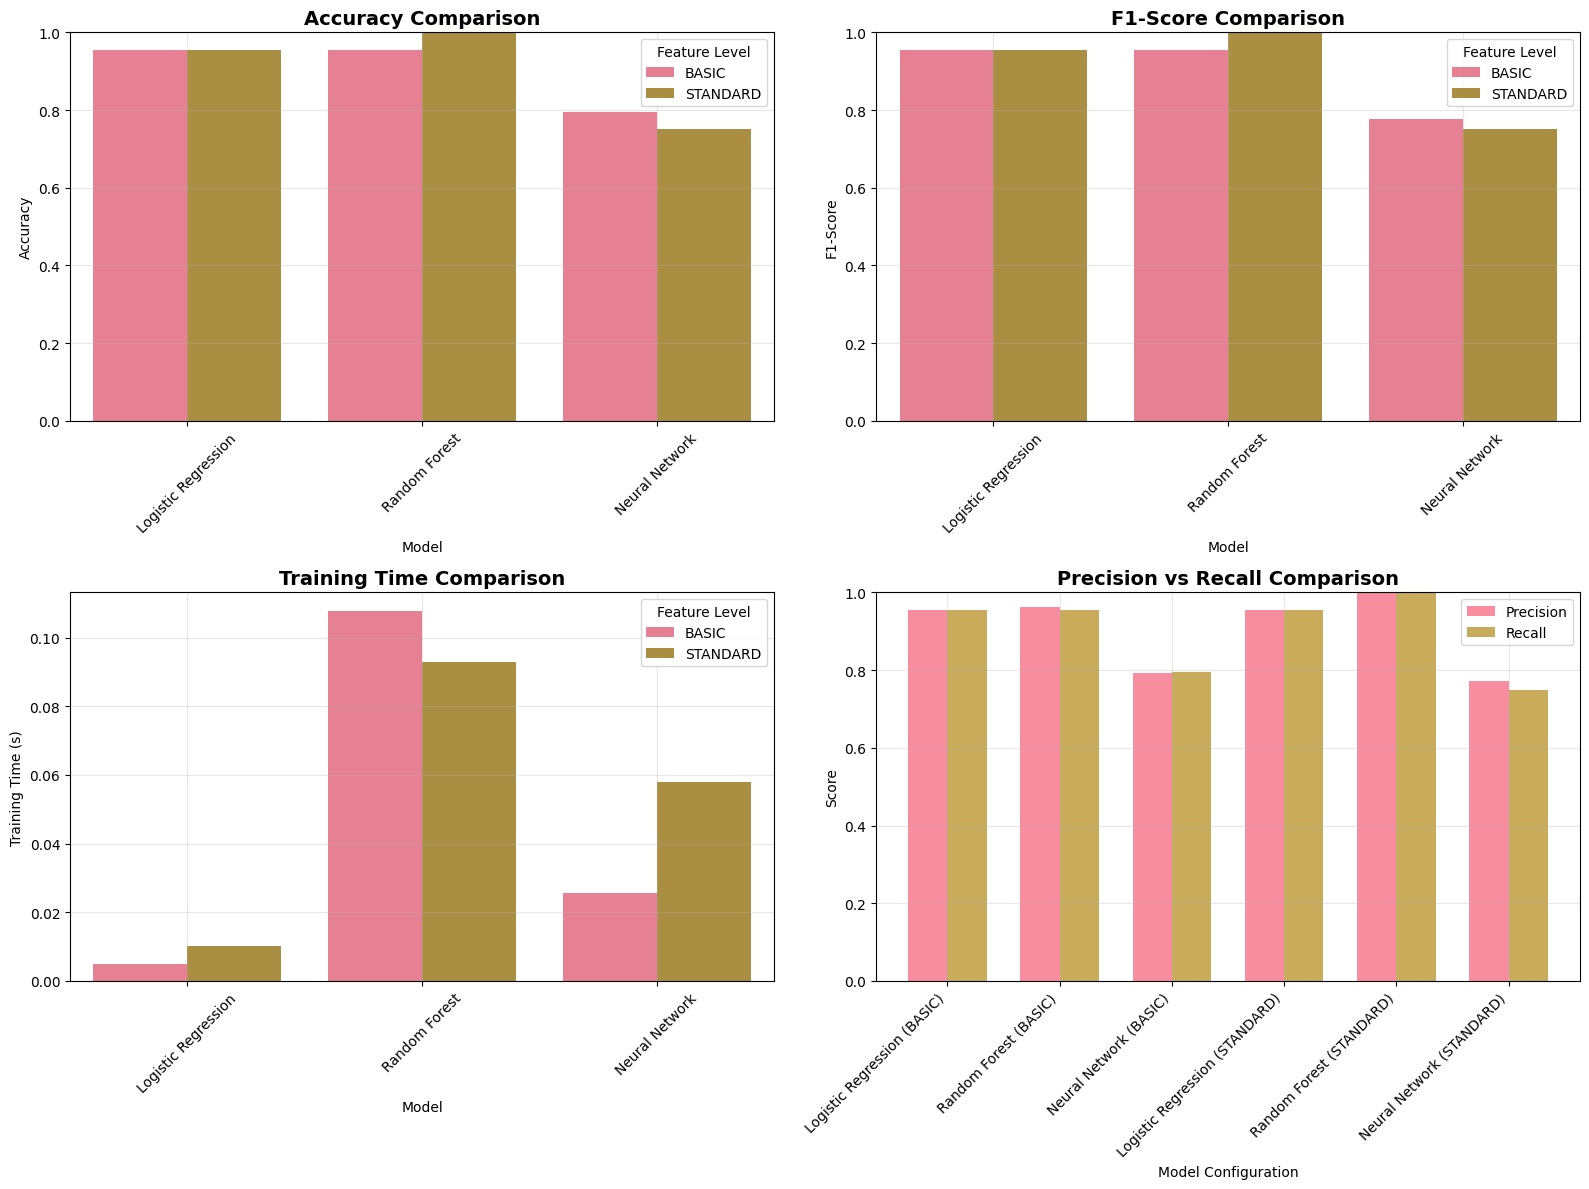

In [18]:
# 📊 Create visualization of results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
feature_levels = list(comparison_results.keys())
models = list(comparison_results[feature_levels[0]].keys())

# 1. Accuracy Comparison
accuracy_data = []
for fl in feature_levels:
    for model in models:
        accuracy_data.append({
            'Feature Level': fl.upper(), 
            'Model': model, 
            'Accuracy': comparison_results[fl][model]['accuracy']
        })
acc_df = pd.DataFrame(accuracy_data)

sns.barplot(data=acc_df, x='Model', y='Accuracy', hue='Feature Level', ax=ax1)
ax1.set_title('Accuracy Comparison', fontweight='bold', fontsize=14)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. F1-Score Comparison  
f1_data = []
for fl in feature_levels:
    for model in models:
        f1_data.append({
            'Feature Level': fl.upper(), 
            'Model': model, 
            'F1-Score': comparison_results[fl][model]['f1']
        })
f1_df = pd.DataFrame(f1_data)

sns.barplot(data=f1_df, x='Model', y='F1-Score', hue='Feature Level', ax=ax2)
ax2.set_title('F1-Score Comparison', fontweight='bold', fontsize=14)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Training Time Comparison
time_data = []
for fl in feature_levels:
    for model in models:
        time_data.append({
            'Feature Level': fl.upper(), 
            'Model': model, 
            'Training Time (s)': comparison_results[fl][model]['training_time']
        })
time_df = pd.DataFrame(time_data)

sns.barplot(data=time_df, x='Model', y='Training Time (s)', hue='Feature Level', ax=ax3)
ax3.set_title('Training Time Comparison', fontweight='bold', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Precision vs Recall Bar Plot
prec_rec_data = []
for fl in feature_levels:
    for model in models:
        prec_rec_data.append({
            'Model': f"{model} ({fl.upper()})",
            'Precision': comparison_results[fl][model]['precision'],
            'Recall': comparison_results[fl][model]['recall'],
            'Feature Level': fl.upper()
        })
pr_df = pd.DataFrame(prec_rec_data)

# Create grouped bar plot
x = np.arange(len(pr_df))
width = 0.35

bars1 = ax4.bar(x - width/2, pr_df['Precision'], width, label='Precision', alpha=0.8)
bars2 = ax4.bar(x + width/2, pr_df['Recall'], width, label='Recall', alpha=0.8)

ax4.set_title('Precision vs Recall Comparison', fontweight='bold', fontsize=14)
ax4.set_xlabel('Model Configuration')
ax4.set_ylabel('Score')
ax4.set_xticks(x)
ax4.set_xticklabels(pr_df['Model'], rotation=45, ha='right')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# See above visualizations for performance comparison insights

---
## 🔍 Step 8.4: Feature Importance Analysis

Understanding which features contribute most to fault detection helps us:
1. **Interpret Model Decisions**: Know what the model is "listening for"
2. **Optimize Feature Sets**: Remove redundant features for faster inference
3. **Validate Physics**: Confirm model uses physically meaningful signals
4. **Guide Sensor Selection**: Focus on the most informative measurements

### 📊 Why Feature Importance Matters in Predictive Maintenance

In industrial settings, knowing which acoustic features detect faults allows you to:
- **Simplify Monitoring**: Focus on key features, reduce computational cost
- **Explain to Stakeholders**: Show maintenance teams what signals indicate failure
- **Design Better Sensors**: Optimize microphone placement and sampling rates
- **Cross-Domain Transfer**: Apply insights to similar equipment types

🔍 FEATURE IMPORTANCE ANALYSIS

📊 Analyzing: Random Forest with STANDARD features
   F1-Score: 1.000
   Method: Gini Importance

Total features: 443

🏆 Top 15 Most Important Features:
mfcc_7_mean                         │ ███  7.69%
mfcc_9_mean                         │ ███  6.26%
energy                              │ ██  4.45%
mfcc_10_mean                        │ █  3.97%
mean                                │ █  3.84%
mfcc_12_mean                        │ █  3.82%
std                                 │ █  3.55%
mfcc_5_mean                         │ █  3.38%
var                                 │ █  3.37%
onset_strength_mean                 │ █  3.36%
mfcc_6_mean                         │ █  3.35%
mfcc_2_mean                         │ █  3.08%
quantile_25                         │ █  2.82%
rms                                 │ █  2.67%
chroma_mean                         │ █  2.66%


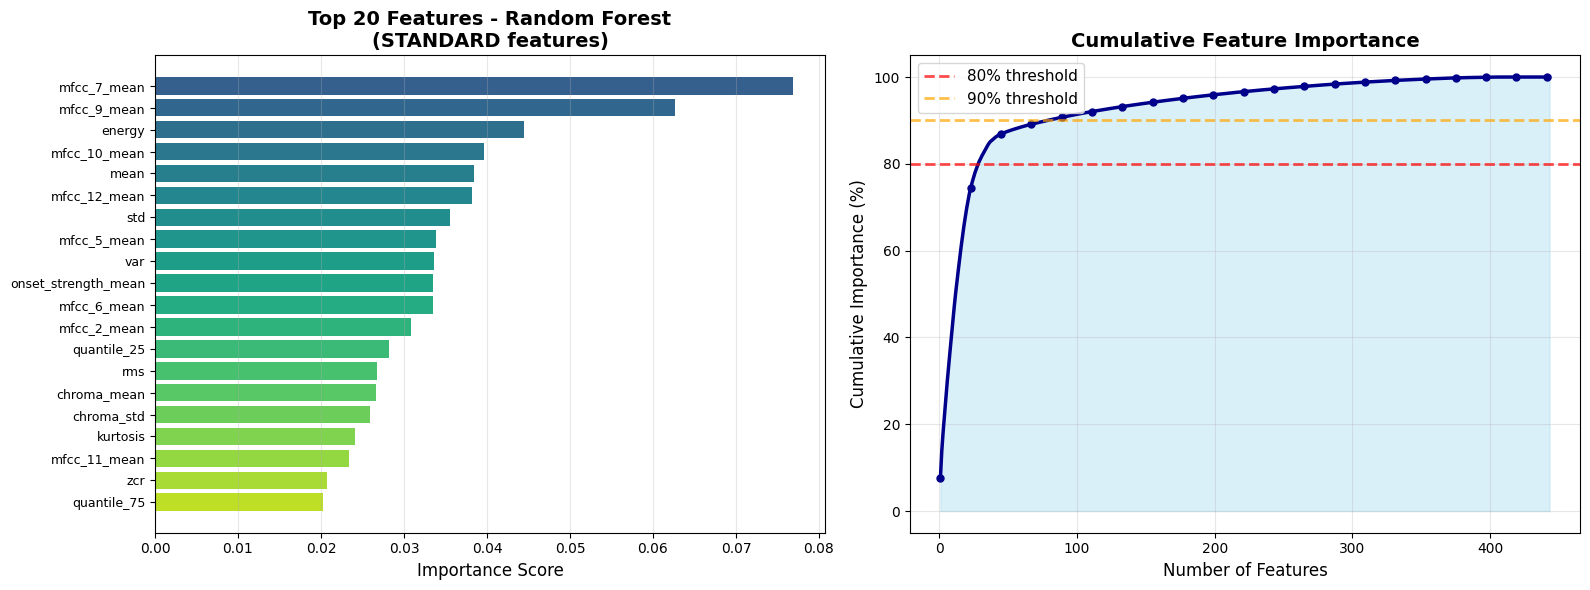


💡 Key Insights:
   • Total features: 443
   • Features for 80% importance: 29 (6.5%)
   • Features for 90% importance: 79 (17.8%)
   • Potential dimensionality reduction: 93.5%

📌 Interpretation:
   Feature importance reveals which acoustic characteristics best discriminate
   between healthy and faulty gears. Just 29 features capture 80%
   of the model's decision-making power, enabling significant dimensionality
   reduction without sacrificing performance - critical for real-time deployment.


In [19]:
# 🔍 Feature Importance Analysis

print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Determine which model performed best and analyze its feature importance
# Find the best performing model across all feature levels
best_model_info = None
best_f1 = 0

for feature_level, models in comparison_results.items():
    for model_name, metrics in models.items():
        if model_name == 'Random Forest' and metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_model_info = {
                'level': feature_level,
                'model': metrics['model'],
                'f1': metrics['f1'],
            }

print(f"\n📊 Analyzing: Random Forest with {best_model_info['level'].upper()} features")
print(f"   F1-Score: {best_model_info['f1']:.3f}")
print(f"   Method: Gini Importance\n")

# Get feature importance from the model
feature_importance = best_model_info['model'].feature_importances_
num_features = len(feature_importance)

# Generate feature names (we'll use generic names since we have many features)
feature_names_for_importance = comparison_results['standard']['Random Forest']['feature_names']
print(f"Total features: {num_features}\n")

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names_for_importance,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Display top 15 features
print(f"🏆 Top 15 Most Important Features:")
for idx, row in importance_df.head(15).iterrows():
    importance_pct = (row['Importance'] / importance_df['Importance'].sum()) * 100
    bar_length = int(importance_pct * 0.5)
    bar = '█' * bar_length
    print(f"{row['Feature']:35s} │ {bar} {importance_pct:5.2f}%")

# Visualize feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of top 20 features
top_n = min(20, len(importance_df))
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))

ax1.barh(range(len(top_features)), top_features['Importance'], color=colors)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['Feature'], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Importance Score', fontsize=12)
ax1.set_title(f'Top {top_n} Features - Random Forest\n({best_model_info["level"].upper()} features)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Cumulative importance curve
cumulative_importance = np.cumsum(importance_df['Importance'])
cumulative_importance_pct = (cumulative_importance / cumulative_importance.iloc[-1]) * 100

ax2.plot(range(1, len(cumulative_importance_pct) + 1), cumulative_importance_pct, 
         linewidth=2.5, color='darkblue', marker='o', markersize=5, markevery=max(1, len(cumulative_importance_pct)//20))
ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, alpha=0.7, label='80% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='90% threshold')
ax2.fill_between(range(1, len(cumulative_importance_pct) + 1), cumulative_importance_pct, 
                 alpha=0.3, color='skyblue')
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax2.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Key insights
features_for_80pct = np.argmax(cumulative_importance_pct >= 80) + 1
features_for_90pct = np.argmax(cumulative_importance_pct >= 90) + 1

print(f"\n💡 Key Insights:")
print(f"   • Total features: {num_features}")
print(f"   • Features for 80% importance: {features_for_80pct} ({features_for_80pct/num_features*100:.1f}%)")
print(f"   • Features for 90% importance: {features_for_90pct} ({features_for_90pct/num_features*100:.1f}%)")
print(f"   • Potential dimensionality reduction: {100 - (features_for_80pct/num_features*100):.1f}%")

print(f"\n📌 Interpretation:")
print(f"   Feature importance reveals which acoustic characteristics best discriminate")
print(f"   between healthy and faulty gears. Just {features_for_80pct} features capture 80%")
print(f"   of the model's decision-making power, enabling significant dimensionality")
print(f"   reduction without sacrificing performance - critical for real-time deployment.")


---
## 🎭 Step 9: Error Analysis via Confusion Matrix

The confusion matrix provides detailed error characterization, revealing classification patterns essential for deployment risk assessment and operational parameter tuning in industrial environments.

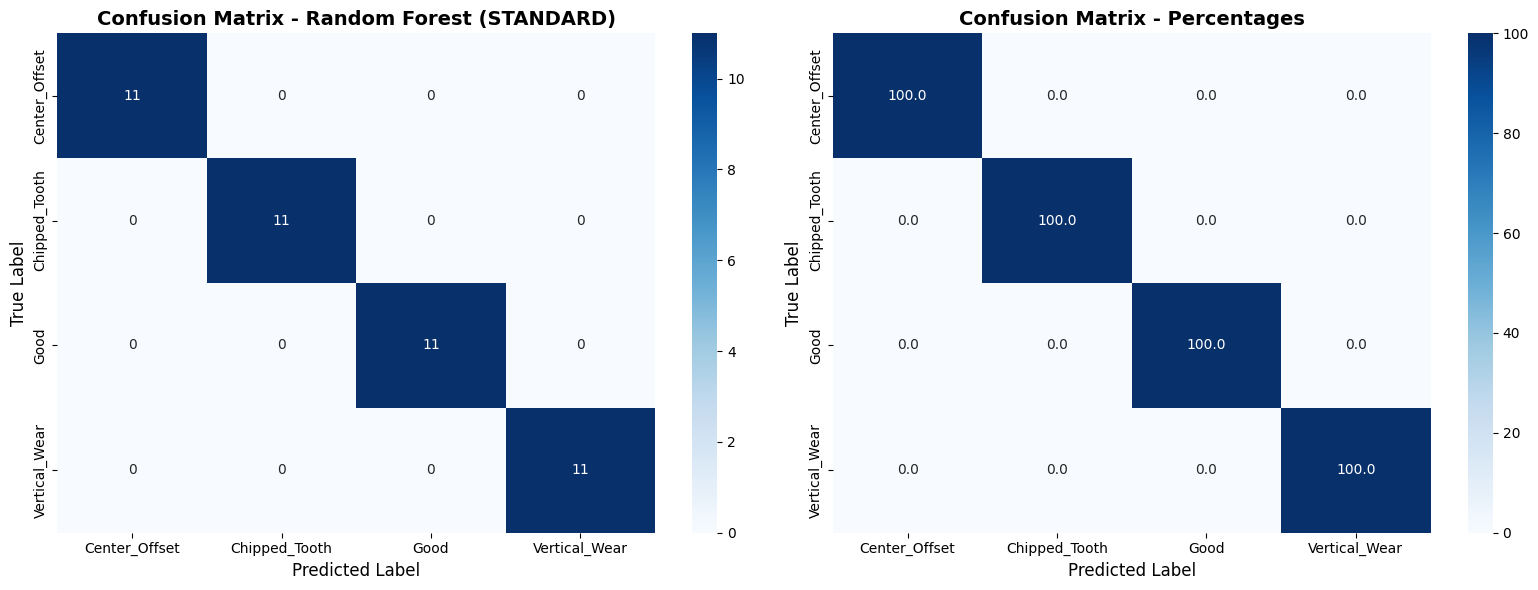


🎯 Model Performance Interpretation:
   📊 Diagonal values (green): Correct predictions - want these HIGH
   ❌ Off-diagonal values: Mistakes - want these LOW


In [20]:
# 🎭 Create confusion matrix for the best model
# Use optimal_config which was already computed in the previous cell
best_feature_level, best_model_name = optimal_config
best_model_results = comparison_results[best_feature_level][best_model_name]

# Get predictions and true labels
y_pred = best_model_results['predictions']
y_test = best_model_results['y_test']
label_encoder = best_model_results['label_encoder']

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
class_names = label_encoder.classes_

# Calculate percentages for better interpretation
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Plot confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title(f'Confusion Matrix - {best_model_name} ({best_feature_level.upper()})', 
              fontweight='bold', fontsize=14)
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)

# Percentages
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title(f'Confusion Matrix - Percentages', fontweight='bold', fontsize=14)
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()


print(f"\n🎯 Model Performance Interpretation:")
print(f"   📊 Diagonal values (green): Correct predictions - want these HIGH")
print(f"   ❌ Off-diagonal values: Mistakes - want these LOW")


---
## 🎯 Step 10: Production Model Training

After validation-based model selection, the final step involves training the optimal configuration on the complete dataset to maximize performance for industrial deployment. This follows established machine learning deployment protocols.

### 💡 Why Retrain on All Data?
1. **📈 Maximum Performance**: Use every available sample for training
2. **🚀 Production Reality**: No "test set" in real deployment
3. **🔬 Validation Complete**: We've already proven the approach works
4. **🏭 Industry Standard**: Common practice for deployment models

### Production Training Methodology

1. **Dataset Consolidation**: Combine training and validation partitions for maximum sample utilization
2. **Performance Maximization**: Leverage all available data to optimize model parameters
3. **Deployment Readiness**: Create production-ready models without holdout constraints
4. **Validation Confidence**: Prior cross-validation ensures generalization capability

### Industrial Deployment Considerations

- **Model Validation**: Cross-validation phase provides generalization confidence
- **Performance Optimization**: Full dataset training maximizes deployment accuracy
- **Operational Monitoring**: Production systems implement continuous performance tracking
- **Update Protocols**: Regular retraining incorporates new operational data

In [21]:
# 🎯 Prepare final deployment model
import joblib
import os
from datetime import datetime

# 🏆 Find the best performing model combination
best_f1 = 0
best_combo = None
best_model_name = None
best_score = 0

for feature_level, models in comparison_results.items():
    for model_name, metrics in models.items():
        current_f1 = metrics['f1']
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_combo = (feature_level, model_name)
            best_model_name = model_name
            best_score = current_f1

print("🎯 Preparing Final Deployment Model...")
print(f"   🏆 Best combination: {best_model_name} with {best_combo[0].upper()} features (F1: {best_score:.3f})")

# 📊 Process complete dataset with best feature level
print("\\n📊 Processing complete dataset...")
complete_data = process_dataset(best_combo[0])  # best feature level

# 🔄 Combine ALL data (train + test) for final training  
X_all = np.vstack([complete_data['X_train'], complete_data['X_test']])
y_all = np.concatenate([complete_data['y_train'], complete_data['y_test']])

print(f"   ✅ Total samples: {len(X_all):,}")
print(f"   ✅ Total features: {X_all.shape[1]:,}")
print(f"   ✅ Classes: {np.unique(y_all)}")

# 🎯 Prepare final data (scaling and encoding)
final_scaler = StandardScaler()
X_all_scaled = final_scaler.fit_transform(X_all)

final_label_encoder = LabelEncoder()
y_all_encoded = final_label_encoder.fit_transform(y_all)

print(f"\\n🔧 Data preparation complete:")
print(f"   📊 Scaled features: mean ≈ {np.mean(X_all_scaled):.3f}, std ≈ {np.std(X_all_scaled):.3f}")
print(f"   🏷️ Encoded labels: {dict(zip(final_label_encoder.classes_, range(len(final_label_encoder.classes_))))}")

# 🤖 Create and train final model (same type as best model)
if best_model_name == 'Logistic Regression':
    final_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
elif best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
elif best_model_name == 'Neural Network':
    final_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42, 
                               early_stopping=True, validation_fraction=0.1)

print(f"\\n🤖 Training final {best_model_name} model...")
start_time = time.time()
final_model.fit(X_all_scaled, y_all_encoded)
training_time = time.time() - start_time

print(f"   ✅ Training complete in {training_time:.2f} seconds")
print(f"   📊 Model trained on {len(X_all):,} samples")

# 💾 Save the deployment model and components
model_dir = Path("trained_models")
model_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"pdm_model_{best_model_name.replace(' ', '_').lower()}_{best_combo[0]}_{timestamp}"

# Save all components needed for deployment
model_files = {
    'model': final_model,
    'scaler': final_scaler, 
    'label_encoder': final_label_encoder,
    'feature_names': complete_data['feature_names'],
    'feature_level': best_combo[0],
    'model_name': best_model_name,
    'training_info': {
        'timestamp': timestamp,
        'samples_used': len(X_all),
        'features_used': X_all.shape[1],
        'classes': list(final_label_encoder.classes_),
        'best_f1_score': best_score,
        'pipeline_params': {
            'segment_seconds': segment_duration,
            'overlap': overlap_ratio,
            'buffer_seconds': edge_buffer
        }
    }
}

# 💾 Save to file
model_path = model_dir / f"{model_filename}.pkl"
joblib.dump(model_files, model_path)

print(f"\\n💾 Model saved for deployment:")
print(f"   📁 Location: {model_path}")
print(f"   📦 Size: {model_path.stat().st_size / 1024:.1f} KB")
print(f"   🏷️ Filename: {model_filename}.pkl")

print(f"\\n🚀 Deployment Package Contents:")
print(f"   🤖 Trained model: {best_model_name}")
print(f"   📊 Feature scaler: StandardScaler fitted on all data")
print(f"   🏷️ Label encoder: {list(final_label_encoder.classes_)}")
print(f"   📋 Feature info: {len(complete_data['feature_names'])} {best_combo[0].upper()} features")
print(f"   ⚙️ Pipeline parameters: Segment={segment_duration}s, Overlap={overlap_ratio}")

# 🎯 Instructions for use
print(f"\\n📖 Usage Instructions:")
print(f"   1. Load model: model_data = joblib.load('{model_filename}.pkl')")
print(f"   2. Extract components: model = model_data['model'], scaler = model_data['scaler']")
print(f"   3. Process new audio with same parameters ({segment_duration}s segments, {best_combo[0]} features)")
print(f"   4. Scale features and predict: scaler.transform(features) → model.predict()")
print(f"   5. Decode predictions: label_encoder.inverse_transform(predictions)")

# Store for live inspector
print(f"\\n🔧 Variables ready for Live Inspector:")
print(f"   final_model, final_scaler, final_label_encoder, complete_data['feature_names']")

🎯 Preparing Final Deployment Model...
   🏆 Best combination: Random Forest with STANDARD features (F1: 1.000)
\n📊 Processing complete dataset...
🔄 Processing dataset with STANDARD features...
   ✅ Train samples: 376 segments
   ✅ Test samples: 44 segments
   ✅ Features per segment: 443
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']
   ✅ Total samples: 420
   ✅ Total features: 443
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']
\n🔧 Data preparation complete:
   📊 Scaled features: mean ≈ 0.000, std ≈ 1.000
   🏷️ Encoded labels: {np.str_('Center_Offset'): 0, np.str_('Chipped_Tooth'): 1, np.str_('Good'): 2, np.str_('Vertical_Wear'): 3}
\n🤖 Training final Random Forest model...
   ✅ Training complete in 0.12 seconds
   📊 Model trained on 420 samples
\n💾 Model saved for deployment:
   📁 Location: trained_models/pdm_model_random_forest_standard_20251104_143327.pkl
   📦 Size: 484.1 KB
   🏷️ Filename: pdm_model_random_forest_standard_20251104_14332

## ? Step 11: Model Persistence & Loading

Implementation of persistent model storage enables distributed workflow where model development and deployment occur in different environments, supporting educational and industrial scenarios requiring model portability.

### 🎓 For Students: Home-to-Class Workflow
- 💾 **Train at home**: Use personal computers for intensive training
- 📁 **Save model**: Export complete model package  
- 🏫 **Load in class**: Import and demonstrate in classroom
- 🚀 **Live demo**: Show real-time predictions instantly

In [22]:
# 🔄 Model Loading System for Live Inspector
from pathlib import Path
import joblib

def load_saved_model(model_path=None):
    """
    Load a previously saved model for live inspection.
    
    Args:
        model_path: Path to saved model file (.pkl)
                   If None, shows available models and prompts user
    
    Returns:
        Dictionary with loaded model components
    """
    
    model_dir = Path("trained_models")
    
    if model_path is None:
        # 📋 Show available models
        if model_dir.exists():
            model_files = list(model_dir.glob("*.pkl"))
            if model_files:
                print("📋 Available Saved Models:")
                print("=" * 60)
                for i, file_path in enumerate(model_files):
                    print(f"   {i+1}. {file_path.name}")
                    
                    # Try to load and show basic info
                    try:
                        model_data = joblib.load(file_path)
                        info = model_data.get('training_info', {})
                        print(f"      🤖 Model: {model_data.get('model_name', 'Unknown')}")
                        print(f"      📊 Features: {model_data.get('feature_level', 'Unknown').upper()}")
                        print(f"      📅 Trained: {info.get('timestamp', 'Unknown')}")
                        print(f"      🎯 F1-Score: {info.get('best_f1_score', 'Unknown')}")
                        print()
                    except Exception as e:
                        print(f"      ⚠️ Error reading file: {e}")
                        print()
                
                print("💡 To load a model, use: load_saved_model('trained_models/filename.pkl')")
                return None
            else:
                print("❌ No saved models found in trained_models/ directory")
                return None
        else:
            print("❌ trained_models/ directory not found")
            return None
    
    # 📦 Load specific model
    try:
        print(f"📦 Loading model from: {model_path}")
        model_data = joblib.load(model_path)
        
        # Validate model components
        required_keys = ['model', 'scaler', 'label_encoder', 'feature_names', 'feature_level']
        missing_keys = [key for key in required_keys if key not in model_data]
        
        if missing_keys:
            print(f"⚠️ Warning: Missing components: {missing_keys}")
        
        # Display model information
        info = model_data.get('training_info', {})
        print(f"\\n✅ Model loaded successfully!")
        print(f"   🤖 Algorithm: {model_data.get('model_name', 'Unknown')}")
        print(f"   📊 Feature Level: {model_data.get('feature_level', 'Unknown').upper()}")
        print(f"   🔧 Features: {len(model_data.get('feature_names', []))}")
        print(f"   🏷️ Classes: {model_data['label_encoder'].classes_}")
        print(f"   📅 Training Date: {info.get('timestamp', 'Unknown')}")
        print(f"   📈 Training Samples: {info.get('samples_used', 'Unknown'):,}")
        print(f"   🎯 Best F1-Score: {info.get('best_f1_score', 'Unknown'):.3f}")
        
        return model_data
        
    except FileNotFoundError:
        print(f"❌ Model file not found: {model_path}")
        return None
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None

# 🔍 Demonstrate model loading system
print("🔍 Model Loading System Demo")
print("=" * 40)

# First, show available models (if any)
loaded_model = load_saved_model()

# If we just trained a model above, we can use that
if 'final_model' in globals():
    print("\\n💡 Using the model we just trained in this session...")
    loaded_model = {
        'model': final_model,
        'scaler': final_scaler,
        'label_encoder': final_label_encoder,
        'feature_names': complete_data['feature_names'],
        'feature_level': best_combo[0],
        'model_name': best_model_name,
        'training_info': {
            'timestamp': timestamp,
            'samples_used': len(X_all),
            'best_f1_score': best_score
        }
    }
    print("✅ Current session model ready for live inspection!")

# 📖 Instructions for students
print("💡 See markdown above for instructions on loading saved models")

🔍 Model Loading System Demo
📋 Available Saved Models:
   1. pdm_model_random_forest_standard_20251103_215142.pkl
      🤖 Model: Random Forest
      📊 Features: STANDARD
      📅 Trained: 20251103_215142
      🎯 F1-Score: 1.0

   2. pdm_model_random_forest_standard_20251103_105458.pkl
      🤖 Model: Random Forest
      📊 Features: STANDARD
      📅 Trained: 20251103_105458
      🎯 F1-Score: 1.0

   3. pdm_model_random_forest_standard_20251104_143327.pkl
      🤖 Model: Random Forest
      📊 Features: STANDARD
      📅 Trained: 20251104_143327
      🎯 F1-Score: 1.0

   4. pdm_model_logistic_regression_basic_20251104_140243.pkl
      🤖 Model: Logistic Regression
      📊 Features: BASIC
      📅 Trained: 20251104_140243
      🎯 F1-Score: 0.9772256728778467

   5. pdm_model_random_forest_basic_20251104_135634.pkl
      🤖 Model: Random Forest
      📊 Features: BASIC
      📅 Trained: 20251104_135634
      🎯 F1-Score: 1.0

   6. pdm_model_random_forest_standard_20251103_173909.pkl
      🤖 Model: Ra

## 🚀 Step 12: Real-Time Deployment System

This section demonstrates the integration of trained models into real-time monitoring systems, bridging offline development with industrial deployment.

### 12.1 Real-Time Monitoring System Integration

### 🏭 What is Live Audio Inspection?

**Live Audio Inspection** continuously monitors equipment by:
1. **📡 Capturing audio** from machinery in real-time
2. **🔧 Processing segments** using identical training parameters  
3. **🤖 Making predictions** with your trained model
4. **📊 Displaying results** with confidence scores and trends
5. **🚨 Alerting operators** when faults are detected

### Live Inspection System Architecture

The real-time monitoring system implements the following operational pipeline:

1. **Signal Acquisition**: Continuous audio capture from industrial equipment
2. **Preprocessing**: Real-time segmentation and feature extraction using identical training parameters
3. **Classification**: Model inference on streaming feature vectors
4. **Decision Logic**: Threshold-based alerting and trend analysis
5. **Operator Interface**: Real-time visualization and notification systems

### Industrial Implementation Considerations

- **Latency Requirements**: Sub-second response times for critical fault detection
- **Computational Constraints**: Edge deployment with limited processing resources
- **Reliability Standards**: High availability and fault tolerance requirements
- **Integration Protocols**: Compatibility with existing SCADA and monitoring infrastructure

In [23]:
# 📋 Show device information for audio capture
try:
    import sounddevice as sd
    print(f"\\n🎤 Available Audio Input Devices:")
    devices = sd.query_devices()
    for i, device in enumerate(devices):
        if device['max_input_channels'] > 0:
            print(f"   {i}: {device['name']} ({device['max_input_channels']} ch, {device['default_samplerate']} Hz)")
    
    default_device = sd.default.device[0] if hasattr(sd.default, 'device') else 'None'
    print(f"\\n📍 Default input device: {default_device}")
    print("\\n💡 To use a specific device, modify the 'device' parameter in the inspector setup")
    
except Exception as e:
    print(f"⚠️ Could not list audio devices: {e}")
    print("   This is normal in some environments - the inspector will use system defaults")

\n🎤 Available Audio Input Devices:
   0: Ibrahim’s iPhone Microphone (1 ch, 48000.0 Hz)
   1: MacBook Pro Microphone (1 ch, 44100.0 Hz)
   3: Immersed (2 ch, 48000.0 Hz)
\n📍 Default input device: 1
\n💡 To use a specific device, modify the 'device' parameter in the inspector setup


In [24]:
#Load your best model for live inspection
model_name='pdm_model_random_forest_standard_20251103_105458.pkl'  # Example filename
loaded_model=load_saved_model(f'trained_models/{model_name}')  # Example path

📦 Loading model from: trained_models/pdm_model_random_forest_standard_20251103_105458.pkl
\n✅ Model loaded successfully!
   🤖 Algorithm: Random Forest
   📊 Feature Level: STANDARD
   🔧 Features: 443
   🏷️ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']
   📅 Training Date: 20251103_105458
   📈 Training Samples: 420
   🎯 Best F1-Score: 1.000


In [25]:
# 🎬 Set up Live Audio Inspector with trained model

def setup_live_inspector(model_data,audio_device=None):
    """
    Configure the Live Audio Inspector with a trained model.
    
    Args:
        model_data: Dictionary with model components from training or loading
    
    Returns:
        Configured LiveAudioInspector instance
    """
    from pathlib import Path
    import importlib.util
    
    # Dynamically load live inspector module
    li_path = Path('Preparation/Sample Preparation/Models/live_inspector.py').resolve()
    spec = importlib.util.spec_from_file_location('live_inspector', str(li_path))
    li_mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(li_mod)
    
    LiveAudioInspector = li_mod.LiveAudioInspector
    
    # Extract model components
    model = model_data['model']
    scaler = model_data['scaler'] 
    label_encoder = model_data['label_encoder']
    feature_names = model_data['feature_names']
    feature_level = model_data['feature_level']
    
    # Get pipeline parameters (with sensible defaults)
    training_info = model_data.get('training_info', {})
    pipeline_params = training_info.get('pipeline_params', {})
    segment_seconds = pipeline_params.get('segment_seconds', 5.0)
    overlap = pipeline_params.get('overlap', 0.5)
    
    print(f"🎬 Setting up Live Inspector: {feature_level.upper()} features, {segment_seconds}s segments")
    
    # Create and configure inspector
    inspector = LiveAudioInspector(
        model=model,
        scaler=scaler,
        segment_seconds=segment_seconds,
        overlap=overlap,
        feature_level=feature_level,
        feature_names=feature_names,
        buffer_duration=10.0,
        device=audio_device,
        lowpass_cutoff=lowpass_cutoff
        
    )
    inspector.label_encoder = label_encoder  # Attach label encoder for decoding
    
    print("✅ Live Inspector ready for real-time monitoring")
    return inspector

# 🎯 Configure live inspector with our model
if 'loaded_model' in globals() and loaded_model is not None:
    live_inspector = setup_live_inspector(loaded_model,audio_device=1)
    print("   📊 Predictions will be displayed with confidence scores")
    print("   📈 Trends and alerts will be shown in real-time")
else:
    print("⚠️ No model loaded - please train a model first or load a saved one")
    live_inspector = None


🎬 Setting up Live Inspector: STANDARD features, 5.0s segments
✅ Live Inspector ready for real-time monitoring
   📊 Predictions will be displayed with confidence scores
   📈 Trends and alerts will be shown in real-time


### 12.2 Production Interface Deployment

The enhanced monitoring interface provides professional-grade visualization and control capabilities for industrial predictive maintenance deployment, demonstrating production-ready system architecture.

In [26]:
from pathlib import Path
import sys

# 🚀 Launch the production monitoring interface

# Add Models directory to Python path
models_path = Path('Preparation/Sample Preparation/Models').resolve()
sys.path.insert(0, str(models_path))


# Import the enhanced UI module (uses ipywidgets for Jupyter)
from enhanced_live_inspector_ui import create_enhanced_live_inspector_ui

print("🎬 Launching Enhanced Live Audio Inspector...")
print("=" * 60)
print("📊 Features:")
print("   • Real-time prediction updates every 2 seconds")
print("   • Automatic CSV logging for production records")
print("   • Machine ID tracking for multi-equipment monitoring")
print("   • Visual alerts and confidence thresholds")
print("   • Label decoding for human-readable predictions")
print("=" * 60)

# Extract label encoder from the loaded model
label_encoder = loaded_model.get('label_encoder', None) if loaded_model else None

# Create and display the enhanced UI with label encoder
ui = create_enhanced_live_inspector_ui(live_inspector, label_encoder=label_encoder)
display(ui)

print("\n✅ Monitoring interface ready!")
print("💡 Instructions:")
print("   1. Enter a Machine ID (e.g., 'Gearbox-A1')")
print("   2. Click 'Start Monitoring' to begin")
print("   3. Speak or play audio - watch real-time predictions!")
print("   4. Click 'Stop Monitoring' when done")
print("   5. Download CSV logs for production records")


🎬 Launching Enhanced Live Audio Inspector...
📊 Features:
   • Real-time prediction updates every 2 seconds
   • Automatic CSV logging for production records
   • Machine ID tracking for multi-equipment monitoring
   • Visual alerts and confidence thresholds
   • Label decoding for human-readable predictions



✅ Monitoring interface ready!
💡 Instructions:
   1. Enter a Machine ID (e.g., 'Gearbox-A1')
   2. Click 'Start Monitoring' to begin
   3. Speak or play audio - watch real-time predictions!
   4. Click 'Stop Monitoring' when done
   5. Download CSV logs for production records


🛑 Plot updater stopped


/Users/ibrahimelkhatib/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ibrahimelkhatib/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ibrahimelkhatib/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


🛑 Plot updater stopped


## 🎓 Workshop Summary: Your ML Journey in Predictive Maintenance

**Congratulations!** You've completed a comprehensive machine learning pipeline for predictive maintenance. Here's what you've accomplished:

### 🧠 **What You've Learned:**
1. **Data Exploration** - Understanding audio signatures of mechanical health
2. **Feature Engineering** - From raw signals to meaningful ML features  
3. **Model Selection** - Comparing algorithms and choosing the best performer
4. **Evaluation Metrics** - Understanding precision, recall, F1-score, and confusion matrices
5. **Model Deployment** - Taking your trained model into real-world monitoring

### 🔧 **Technical Skills Gained:**
- Audio signal processing with librosa
- Feature extraction at multiple complexity levels
- Machine learning model comparison and selection
- Model persistence and loading for production use
- Real-time audio monitoring and prediction

### 🏭 **Industrial Applications:**
Your trained model can now detect mechanical issues in:
- Manufacturing equipment
- HVAC systems  
- Automotive diagnostics
- Industrial pumps and motors
- Any rotating machinery with audio signatures

### 🚀 **Next Steps:**
1. **Experiment** with different audio recordings
2. **Collect** your own machinery audio data
3. **Expand** the feature set with domain knowledge
4. **Deploy** in real industrial environments
5. **Monitor** and retrain with new data

### 💡 **Key Takeaway:**
Machine learning in predictive maintenance isn't just about algorithms - it's about understanding the physics of failure, extracting meaningful features, and deploying robust monitoring systems that keep industry running smoothly!

---
**🎯 You're now equipped to build ML solutions for real-world predictive maintenance challenges!**